<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/EDA_ML_densidadRT_diag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En esta aplicación, se estudiará el impacto que tienen los equipos de radioterapia externa como los Linacs y Cobalto así como el PIB per capita en la tasa de mortalidad.

In [1]:

# !pip install jedi
# !sudo apt update && sudo apt-get install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2
# !pip install --upgrade --force-reinstall kaleido plotly
# !pip install pwlf


/bin/bash: line 1: plotly_get_chrome: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.5 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,751 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-se

In [1]:
!plotly_get_chrome


Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: None
Do you want to proceed? [y/n] y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [3]:
from pathlib import Path
import unicodedata
import requests
from urllib.parse import quote

import numpy as np
import pandas as pd
import os

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
# --- Estadística ---
from scipy import stats
from scipy.stats import shapiro, linregress
from scipy.signal import find_peaks

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# --- Statsmodels ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Machine Learning (sklearn) ---
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_val_predict
)

from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score,
    classification_report, roc_auc_score, roc_curve
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, ElasticNetCV,
    LogisticRegression, HuberRegressor
)

from sklearn.tree import DecisionTreeRegressor, plot_tree

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.inspection import PartialDependenceDisplay, partial_dependence

# --- Otros ---
import pwlf
from scipy.cluster.hierarchy import fclusterdata


#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

Carga de datos ya depurados, la depuración se hizo en el fichero depuración.

In [5]:
url = "https://raw.githubusercontent.com/mehrerm/TFM/main/data/processed/"
#df_merged = pd.read_csv(url + "df_merged_WHO.csv")

#se ha cargado el dataset el cual tiene información adicional sobre equipos de
#radiodiagnostico
df_merged = pd.read_csv(url + "df_merged_WHO_diag_.csv")
display(df_merged.head())

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer label,Sex,Type,ASR (World),...,Total,Region Name,Year_Units,RT_m,GDP_per_capita,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,...,109,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,...,55,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,...,177,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,...,65,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,...,33,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


In [6]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               1085 non-null   int64  
 1   Population         1085 non-null   float64
 2   Population_male    1085 non-null   float64
 3   Population_female  1085 non-null   float64
 4   ISO3               1085 non-null   object 
 5   Population id      1085 non-null   int64  
 6   Cancer label       1085 non-null   object 
 7   Sex                1085 non-null   object 
 8   Type               1085 non-null   object 
 9   ASR (World)        1085 non-null   float64
 10  Crude rate         1085 non-null   float64
 11  Cumulative risk    1085 non-null   float64
 12  Total              1085 non-null   int64  
 13  Region Name        1085 non-null   object 
 14  Year_Units         1085 non-null   int64  
 15  RT_m               1085 non-null   float64
 16  GDP_per_capita     1085 

In [7]:
df_merged.isna().sum()[df_merged.isna().sum() > 0]

,0
TAC,445
GammaC,525
MRI,435
Mammography,715
PET,485




Como existen muchos datos missing, lo que se hará con estas variables es usarlas como descriptivas. En el caso de los mamógrafos, se decidió eliminarlos de nuestro dataset, ya que son muchos missing.



Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer, y saber la disponibilidad de los datos. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad a lo largo de los tres años que se tienen registros de equipos de radioterapia (2015-2018-2020), y si existen diferencias sistemáticas por sexo y detectar patrones globales.

Varias de las variables son irrelevantes para este estudio, así que se eliminan del dataset.





In [8]:
df_merged = df_merged.drop(columns=['Crude rate', 'Cumulative risk', "Year_Units", 'Total', "Mammography"])

In [9]:
df_merged.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer label,Sex,Type,ASR (World),Region Name,RT_m,GDP_per_capita,TAC,GammaC,MRI,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0


Entre las variables se tiene:

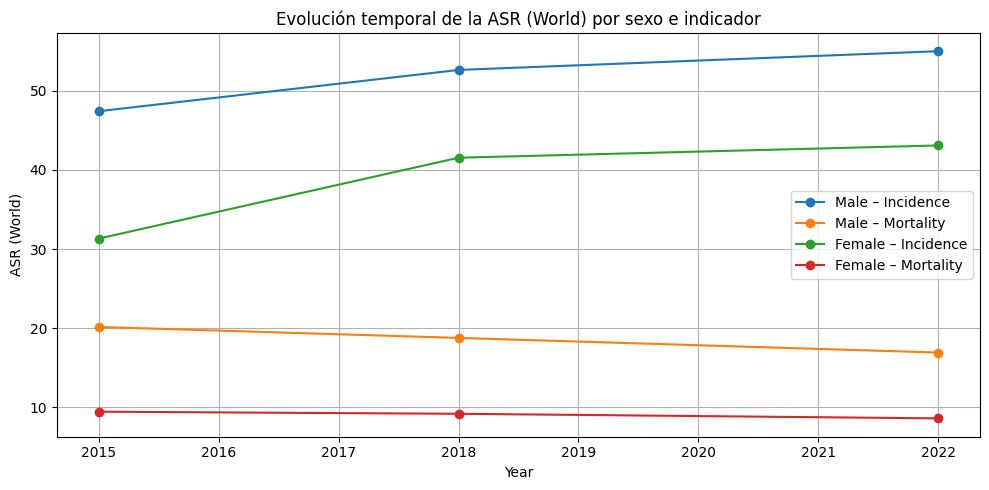

In [10]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

En la serie temporal no parece evidenciar o estar afecto por el COVID19, los datos del 2018 y 2022 son bastante parecidos, esto también nos podría suponer que no ha evolucionado significativamente la tasa de mortalidad, lo que si queda claro, es que los hombres y mujeres tienen incidencias y mortalidad distintas, con casi los mismo comportamientos pero de magnitud diferente.
En nuestro estudio existen solamente tres años porque son los años que se tiene registro de la cantidad de equipos de radioterapia y su evolución a lo largo de esos tres años registrados, como ya se mencionó en la depuración, se consideró sumarle 5 años a los registros  de los equipos ya que es ese tiempo aproximadamente en el que se puede saber la efectividad de un tratamiento de esa naturaleza.





Se busca entonces ver como se comporta la mortalidad e incidencia por año, graficando los tres años y ver si hay outliers

In [11]:
idx = (
    df_merged
    .groupby(["ISO3", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

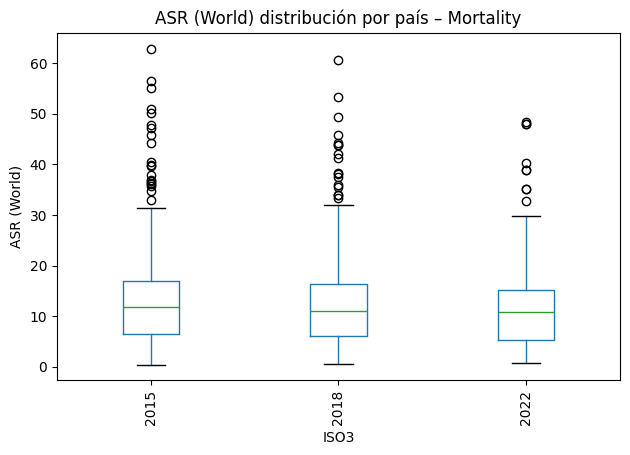

<Figure size 1000x500 with 0 Axes>

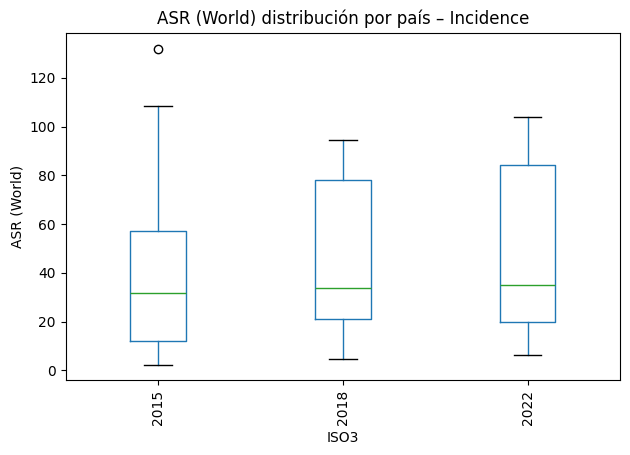

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  210.0  37.760526  29.306871  2.279390  11.796643  31.704972   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2022   30.0  47.842069  34.262574  6.242416  19.646427  34.806863   
Mortality 2015  300.0  13.748971  10.739895  0.388140   6.419846  11.762913   
          2018  280.0  13.035889  10.141584  0.541023   6.052555  11.010309   
          2022  245.0  11.950008   8.931221  0.668701   5.359303  10.791069   

                      75%         max  
Type      Year                         
Incidence 2015  57.320187  132.046692  
          2018  77.994580   94.690075  
          2022  84.118158  103.896318  
Mortality 2015  17.032979   62.917421  
          2018  16.400917   60.588763  
          2022  15.227584   48.374439  


In [12]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("ISO3")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran que la mortalidad presenta una elevada heterogeneidad entre países, con la presencia de valores atípicos claramente por encima de la media. Por el contrario, la incidencia exhibe una distribución más homogénea.

En el caso de la mortalidad, esta heterogeneidad podría estar relacionada con diferencias en la disponibilidad y calidad de los sistemas de registro sanitario. Los países con sistemas estadísticos más consolidados y con un mayor control y seguimiento de los equipos y protocolos médicos tienden a registrar y reportar de forma más sistemática la información relativa al cáncer, que posteriormente es compartida con fuentes internacionales. Por el contrario, en países en conflicto o con menor nivel de desarrollo económico, estos registros suelen ser incompletos o inexistentes.

Como consecuencia, solo un número reducido de países presenta valores de mortalidad elevados correctamente registrados, lo que da lugar a la aparición de valores atípicos en la distribución observada.

Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad, ya que la incidencia es el mejor indicativo sobre la efectividad de multiples tratamientos.


Es importante resaltar desde el principio de que nuestra variable objetivo es la tasa de mortalidad  en ASR (World) y ver que relación tiene con los equipos de radioaterapia, incidencia, PIB per capita, sexo, región, etc.



In [13]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["ISO3", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("ISO3")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 648
Con incidencia y mortalidad: 152
Solo incidencia: 48
Solo mortalidad: 448
Type  both  only_incidence  only_mortality
Year                                      
2015   136              32             104
2018     8               8             216
2022     8               8             128


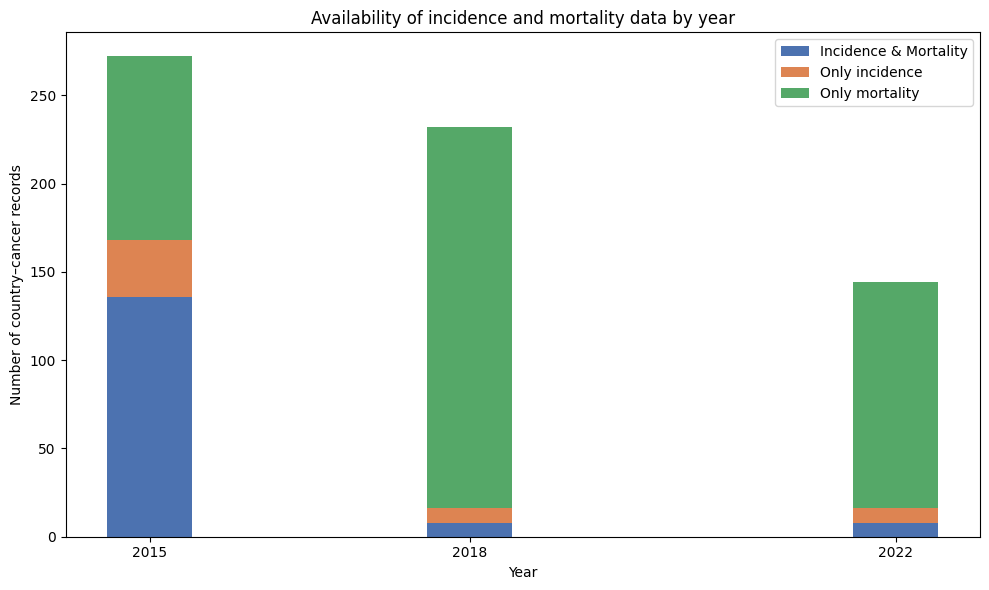

In [14]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/Incidence_mortality_data_year.jpg", dpi=300, bbox_inches="tight")
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos de incidencia disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de mortalidad como variable objetivo, Debido a la escasez de datos disponibles, el análisis no se realiza de forma estratificada por año. Se reconoce la posible presencia de colinealidad temporal; no obstante, el propósito del estudio es explorar la metodología para valorar la necesidad de equipamiento de radioterapia bajo un supuesto de disponibilidad de datos más sólidos y homogéneos.

In [15]:

df_merged_all = df_merged.copy()


# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()



# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


,count
Year,
2015,300
2018,280
2022,245


Con estos datos, se procede a evaluar con gráficos y estadísitcas que se tiene por cada tipo de cancer.

In [16]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

In [17]:
#Se renombran las columnas
df_model = df_merged_all.rename(columns={
    "Cancer label": "Cancer",
    "Region Name": "Region",
   #"Country_harmonized": "Country",
    "ASR (World)" : "ASR",
    "GDP_per_capita" : "GDP",
    "RT_m" : "RT"
})




In [18]:
df_model.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer,Sex,Type,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0


Con la finalidad de entender si existe algún patrón de comportamiento de estos tipos de cancer con variables como PIB y RT, se procede a utilizar graficos de dispersión.

Se cambia a escala logaritmica el PIB.

In [19]:
df_model['log_GDP'] = np.log(df_model['GDP'])

In [20]:
df_model.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer,Sex,Type,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET,log_GDP
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695


Las variables disopnibles son las siguientes:
* Year = el año del registro, para los equipos de radiodiagnostico y radioterapia, se han sumado 5 años.
* Population = poblacion de ese año
* Population_male = población masculina
* Population_female = población femenina
* ISO3 = país en codigo iso
* Population id = país en codigo numerico
* Cancer = tipo de cáncer, en este dataset se tiene: próstata, mama, pulmón (ambos sexos) y cervix.
* Sex = sexo
* Type = tipo de tasa de insidencia o mortalidad
* ASR = tasa de incidencia o mortalidad acorde a la normalización poblacional por edad
* Region = continente o regioon
* RT = densidad de equipos de radioterapia externa (linacs o cobalto) por millon de habitantes
* GDP = PIB per capita
* TAC,	GammaC,	MRI,	PET = equipos de radiodiagnostico por millón de habitantes.
* log_GDP PIB per capita a escala logaritmica.

In [21]:

# pio.templates.default = "plotly_white"
# pio.kaleido.scope.default_format = "png"
# pio.kaleido.scope.default_width = 1200
# pio.kaleido.scope.default_height = 800
# pio.kaleido.scope.default_scale = 2
pio.defaults.default_template = "plotly_white"
pio.defaults.default_scale = 2
pio.defaults.default_height = 800
pio.defaults.default_width = 1200
pio.defaults.default_format = "png"

def plot_all_cancers(df, x, y):
    fig = px.scatter(
        df,
        x=x,
        y=y,
        color="Cancer",
        facet_col="Sex",
        facet_row="Year",
        hover_name="ISO3",
        title=f"Grafica de dispersion entre {x} y {y} por tipo de cáncer, año y sexo"
    )
    fig.update_layout(height=800, width=1000)
    fig.write_image(f"{fig_dir}/scatter_{x}_vs_{y}_by_sex.png", scale=3)
    fig.show()


plot_all_cancers(df_model, "log_GDP", "ASR")

plot_all_cancers(df_model, "RT", "ASR")


Se observa una tendencia general a que, crece el PIB per cápita (log_GDP) con el ASR y en cierto punto es que empieza a bajar ASR, esto posiblemente se debe al tabaquismo, contaminación u otro factor no lineal. Esto sugiere que el desarrollo económico hasta cierto punto puede ayudar, asi conjuntamente el sistema sanitario, ambos juegan un papel crucial en la reducción de la mortalidad por cáncer. Sin embargo, esta relación es confusa y varía entre cánceres. Por ejemplo, algunos cánceres pueden mostrar una disminución más pronunciada que otros a medida que aumenta el PIB.

ASR vs. Radioterapia (RT): La relación entre la disponibilidad de equipos de radioterapia y la mortalidad es más compleja y específica de cada cáncer.

Cáncer de Cérvix: Visualmente, es probable que se observe que un aumento en la disponibilidad de RT se correlaciona con una disminución en la ASR, especialmente en rangos bajos de RT, lo que podría ser debido a un efecto umbral. Los puntos de datos para este cáncer se concentran en la parte inferior izquierda de los gráficos cuando hay poca RT y se desplazan aún mas hacia abajo y a la derecha a medida que aumenta la RT.
Cáncer de Mama y Próstata: Para estos cánceres, la relación con la RT parece menos consistente o más dispersa. Los puntos de datos pueden estar más agrupados o mostrar una correlación más débil.

Diferencias por Sexo: Los gráficos revelan que las tendencias pueden variar entre hombres y mujeres para el mismo tipo de cáncer, y también a lo largo de los años, usando el cancer de pulmon para este fin.

Se separan por sexo debido a los comportamientos y tipos de cancer


In [22]:
df_model_f = df_model[df_model["Sex"] == "Female"].copy()
df_model_f.drop(columns=["Population_male", "Type", "Sex"], inplace=True)


In [23]:
df_model_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 1 to 1084
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               495 non-null    int64  
 1   Population         495 non-null    float64
 2   Population_female  495 non-null    float64
 3   ISO3               495 non-null    object 
 4   Population id      495 non-null    int64  
 5   Cancer             495 non-null    object 
 6   ASR                495 non-null    float64
 7   Region             495 non-null    object 
 8   RT                 495 non-null    float64
 9   GDP                495 non-null    float64
 10  TAC                288 non-null    float64
 11  GammaC             252 non-null    float64
 12  MRI                294 non-null    float64
 13  PET                261 non-null    float64
 14  log_GDP            495 non-null    float64
dtypes: float64(10), int64(2), object(3)
memory usage: 61.9+ KB


In [24]:
df_model_m = df_model[df_model["Sex"] == "Male"].copy()
df_model_m.drop(columns=["Population_female", "Type", "Sex"], inplace=True)
df_model_m.head()


,Year,Population,Population_male,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET,log_GDP
0,2015,1292275.0,648341.0,MUS,480,Lung,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
3,2015,1292275.0,648341.0,MUS,480,Prostate,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
5,2018,1288833.0,646826.0,MUS,480,Lung,10.543072,Africa,2.41,11818.748062,6.43,2.41,4.82,0.0,9.377442
8,2018,1288833.0,646826.0,MUS,480,Prostate,12.165378,Africa,2.41,11818.748062,6.43,2.41,4.82,0.0,9.377442
10,2022,1276130.0,638999.0,MUS,480,Lung,10.937588,Africa,3.14,10246.501746,NaN,NaN,NaN,NaN,9.234692


In [25]:
df_model_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 1083
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             330 non-null    int64  
 1   Population       330 non-null    float64
 2   Population_male  330 non-null    float64
 3   ISO3             330 non-null    object 
 4   Population id    330 non-null    int64  
 5   Cancer           330 non-null    object 
 6   ASR              330 non-null    float64
 7   Region           330 non-null    object 
 8   RT               330 non-null    float64
 9   GDP              330 non-null    float64
 10  TAC              192 non-null    float64
 11  GammaC           168 non-null    float64
 12  MRI              196 non-null    float64
 13  PET              174 non-null    float64
 14  log_GDP          330 non-null    float64
dtypes: float64(10), int64(2), object(3)
memory usage: 41.2+ KB


Ahora, se buscan las variables que nos interesa


Con el objetivo de identificar las variables que podrían influir en la tasa de mortalidad, se realiza un análisis mediante una matriz de correlaciones, diferenciando por sexo, dado que los patrones de mortalidad presentan comportamientos significativamente distintos entre hombres y mujeres.

In [26]:
df = df_model_m.copy()


cols_corr_m = [
    "ASR", "RT", "log_GDP"
]

In [27]:


corr_m = df[cols_corr_m].corr()
corr_m

,ASR,RT,log_GDP
ASR,1.000000,0.017513,-0.018381
RT,0.017513,1.000000,0.755825
log_GDP,-0.018381,0.755825,1.000000


In [28]:



cols_corr_f = [
    "ASR", "RT", "log_GDP"
]
df[cols_corr_f].corr()

,ASR,RT,log_GDP
ASR,1.000000,0.017513,-0.018381
RT,0.017513,1.000000,0.755825
log_GDP,-0.018381,0.755825,1.000000


Lo que se puede ver es que la señal es bastante débil y contradictoria tanto para hombres como mujeres si juntamos todos los tipos de cancer, ahora bien, si los esparamos

In [29]:
def plot_corr_heatmap(df, cols_corr, cancer):
  df_ = df[df["Cancer"] == cancer]
  # Determine sex from the dataframe passed
  current_sex = "Male" if "Population_male" in df.columns else "Female"

  corr_ = df_[cols_corr].corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(
    corr_,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
  )
  plt.title("Correlation heatmap – " f"{cancer}")
  plt.tight_layout()
  # Save the figure BEFORE showing it
  plt.savefig(f"{fig_dir}/heatmap_corr_{cancer}_{current_sex}.jpg", dpi=300, bbox_inches="tight")
  plt.show()

  return corr_, df_

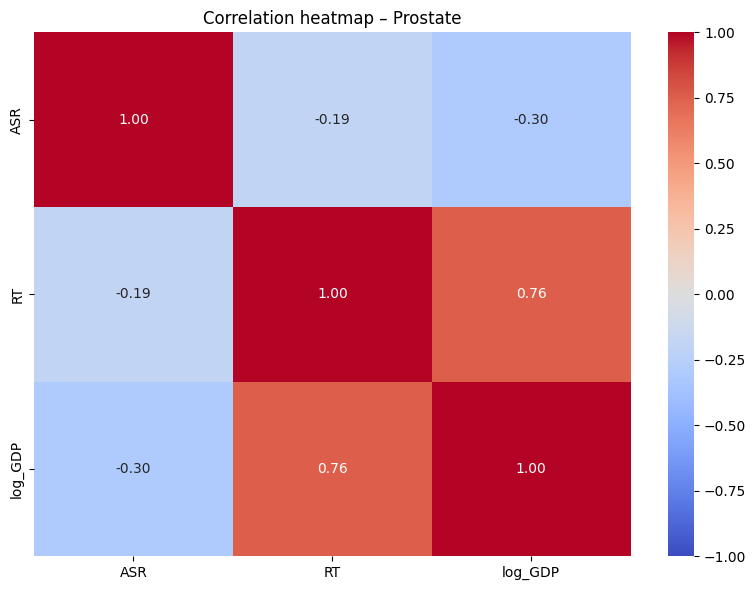

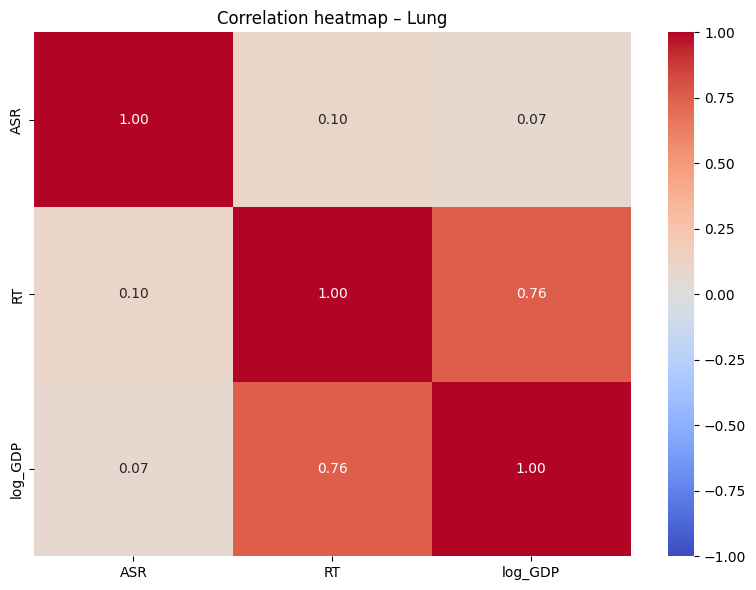

In [30]:
corr_prostate, df_prostate = plot_corr_heatmap(df_model_m, cols_corr_m, "Prostate")

corr_lung_m, df_lung_m = plot_corr_heatmap(df_model_m, cols_corr_m, "Lung")


En estos mapas de calor podemos ver una muy fuerte correlación entre el pib per capita y los equipos RT, esto tiene sentido ya que los equipos de radioterapia podrían costar 3millones de € además de la infraestructura requerida, mantenimiento, personal, etc, algo que en general, los países con per cápita alto se pueden permitir.

In [31]:
df = df_model_f.copy()


cols_corr_f = [
    "ASR", "RT", "log_GDP"
]

corr = df[cols_corr_f].corr()
corr

,ASR,RT,log_GDP
ASR,1.000000,0.072251,0.031906
RT,0.072251,1.000000,0.755825
log_GDP,0.031906,0.755825,1.000000


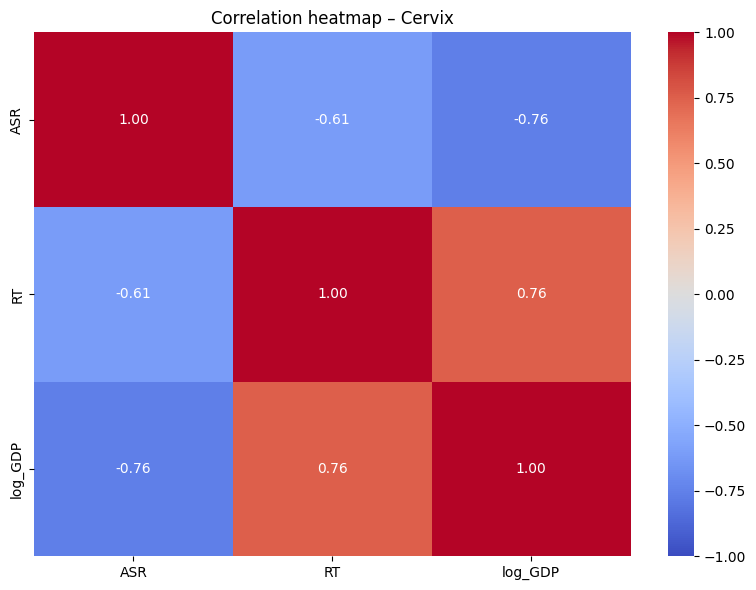

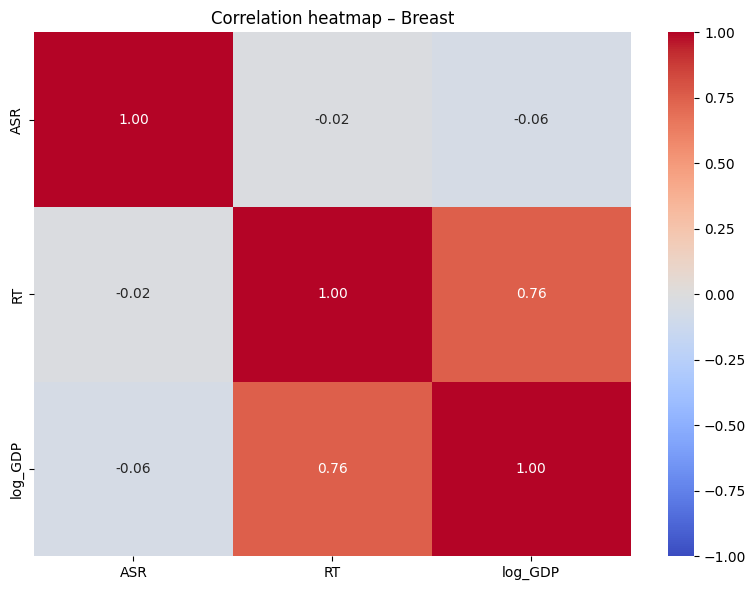

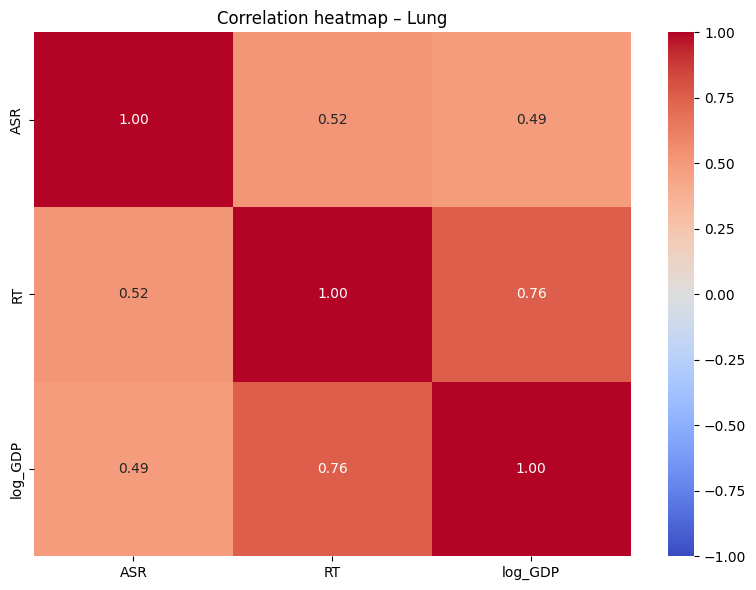

In [32]:
corr_cervix, df_cervix = plot_corr_heatmap(df_model_f, cols_corr_f, "Cervix")

corr_breast, df_breast = plot_corr_heatmap(df_model_f, cols_corr_f, "Breast")

corr_lung_f, df_lung_f = plot_corr_heatmap(df_model_f, cols_corr_f, "Lung")

Analizando los mapas de calor, encontramos que paradojicamente existen tipos de cáncer que aumentan con la cantidad de equipos y PIB per capita, este es el caso de pulmón en ambos sexos, sin embargo, se puede ver claramente que para cervix, que estan muy bien protocolizados en tratamientos con radioterapia externa, si tienen un gran impacto, el valor negativo nos indica que disminuye a media que aumenta el número de la variable predictora. Esto ocurre tanto para RT como el PIB.



A partir de aquí y debido a que tenemos dos variables predictoras, utilizaremos métodos adecuados al numero de observaciones y variables.

¿Existe un umbral de numero de RT donde se puede optimizar sus bondades y aún así optener buenos resultados epidemiológicos tanto en próstata como en cervix?
O ¿Entre más equipos existe menos mortalidad?

Se puede ver mediante correlaciones que quien realmente parece tener influencia de comportamiento sobre la tasa de mortalidad es el cáncer de cervix.

Empezando con un modelo base sencillo regresión lineal, se hará para todos los tipo de cáncer que se tienen registros en este dataset.

### Regresión lineal para próstata con ambas variables (ASR ~ log_GDP + RT)

In [33]:
model_prostate_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_prostate
).fit()

print(model_prostate_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     8.125
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           0.000434
Time:                        13:03:38   Log-Likelihood:                -484.55
No. Observations:                 165   AIC:                             975.1
Df Residuals:                     162   BIC:                             984.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.2940      4.968      5.696      0.0

Con un modelo OLS sencillo, explica en su conjunto solamente el 9% de la variabilidad se debe a estas variables y paradojicamente, RT en positivo y estadisticamente sin significancia, sin embargo, el PIB lo es,por lo tanto, no hay suficiente evidencia si RT tenga un efecto lineal.

### Evaluación de RMSE y Validación Cruzada para Cáncer de Próstata

In [34]:
# --- RMSE para el modelo OLS de Próstata ya ajustado ---
X_prostate = df_prostate[["log_GDP", "RT"]]
y_pred_prostate = model_prostate_ols.predict(X_prostate)
rmse_prostate = np.sqrt(mean_squared_error(df_prostate["ASR"], y_pred_prostate))
print(f"RMSE (Modelo OLS Próstata): {rmse_prostate:.3f}")

# --- Validación Cruzada para Próstata ---

y_prostate = df_prostate["ASR"]

lr_prostate = LinearRegression()
cv_prostate = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_prostate = cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="r2"
)

rmse_scores_prostate = -cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Próstata): {r2_scores_prostate.mean():.3f} ± {r2_scores_prostate.std():.3f}")
print(f"CV RMSE (Próstata): {rmse_scores_prostate.mean():.3f} ± {rmse_scores_prostate.std():.3f}")

RMSE (Modelo OLS Próstata): 4.562
CV R² (Próstata): 0.010 ± 0.119
CV RMSE (Próstata): 4.627 ± 0.707


### Cancer de Cervix (ASR ~ log_GDP + RT)

In [35]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     110.8
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           4.81e-31
Time:                        13:03:38   Log-Likelihood:                -326.95
No. Observations:                 165   AIC:                             659.9
Df Residuals:                     162   BIC:                             669.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.7322      1.911     11.893      0.0

In [36]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP",
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     220.1
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           4.68e-32
Time:                        13:03:38   Log-Likelihood:                -327.56
No. Observations:                 165   AIC:                             659.1
Df Residuals:                     163   BIC:                             665.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.1711      1.389     17.402      0.0

Con resultados donde se predice el 58% de la variabilidad, se puede decir que el PIB per capita es el dominante y el intervalo está lejos de cero. Esto es coherente con que la infraestructura sanitaria está correlacionada con desarrollo economico, sin embargo, RT tiene poca significancia, demostrando aqui que posiblemente tiene un comportamiento no lineal.

### Evaluación de RMSE y Validación Cruzada para Cáncer de Cérvix considerando RT

In [37]:
# --- RMSE para el modelo OLS de Cérvix ya ajustado ---
y_pred_cervix = model_cervix_ols.predict(df_cervix)
rmse_cervix = np.sqrt(mean_squared_error(df_cervix["ASR"], y_pred_cervix))
print(f"RMSE (Modelo OLS Cérvix): {rmse_cervix:.3f}")

# --- Validación Cruzada para Cérvix ---
X_cervix = df_cervix[["log_GDP", "RT"]]
y_cervix = df_cervix["ASR"]

lr_cervix = LinearRegression()
cv_cervix = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_cervix = cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="r2"
)

rmse_scores_cervix = -cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Cérvix): {r2_scores_cervix.mean():.3f} ± {r2_scores_cervix.std():.3f}")
print(f"CV RMSE (Cérvix): {rmse_scores_cervix.mean():.3f} ± {rmse_scores_cervix.std():.3f}")

RMSE (Modelo OLS Cérvix): 1.762
CV R² (Cérvix): 0.556 ± 0.081
CV RMSE (Cérvix): 1.756 ± 0.228


In [38]:
df_cervix.describe()

,Year,Population,Population_female,Population id,ASR,RT,GDP,TAC,GammaC,MRI,PET,log_GDP
count,165.000000,1.650000e+02,1.650000e+02,165.000000,165.000000,165.000000,165.000000,96.000000,84.000000,98.000000,87.000000,165.000000
mean,2018.096970,3.089068e+07,1.561041e+07,406.406061,3.667999,4.536242,29072.858533,15.580312,6.071786,8.117041,1.147851,9.870272
std,2.839667,5.935653e+07,2.973329e+07,237.368703,2.708875,3.416306,24669.242946,17.239903,7.086268,9.026534,1.615940,0.988413
min,2015.000000,3.563330e+05,1.771300e+05,32.000000,0.388140,0.000000,1283.520304,0.000000,0.000000,0.000000,0.000000,7.157362
25%,2015.000000,4.323387e+06,2.086352e+06,208.000000,1.446800,1.470000,10024.819111,5.047500,1.212500,1.415000,0.023000,9.212819
50%,2018.000000,9.064677e+06,4.574595e+06,380.000000,3.074132,3.960000,20221.103686,12.720000,3.565000,5.515000,0.470000,9.914482
75%,2022.000000,3.729500e+07,1.878008e+07,608.000000,5.101708,6.780000,41929.754911,18.922500,8.407500,10.345000,1.605000,10.643751
max,2022.000000,3.415340e+08,1.698613e+08,862.000000,13.175513,13.160000,116926.759594,101.700000,48.370000,46.160000,8.290000,11.669303


El error medio de ambos modelos OLS y validación cruzada nos indica que el modelo se equivoca en promedio +/- 1.8 muertes/100K, el modelo explica más de 50% de la variabilidad asi como para validación cruzada, siendo entonces en este caso, un buen modelo para explicar el comportamiento del cancer de cervix, donde el PIB per capita es quien tiene mayor significancia.

### Para mama cancer de mama

In [39]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.3468
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.707
Time:                        13:03:38   Log-Likelihood:                -434.27
No. Observations:                 165   AIC:                             874.5
Df Residuals:                     162   BIC:                             883.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.2410      3.663      4.434      0.0

In [40]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5302
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.468
Time:                        13:03:39   Log-Likelihood:                -434.35
No. Observations:                 165   AIC:                             872.7
Df Residuals:                     163   BIC:                             878.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.2148      2.653      5.734      0.0

Con respecto al cancer de mama, las variables carecen de significancia y explican tan solo el 0.3% de la variabilidad, asumiendo que en este caso, existen factores externos como la detección precoz, cirguría y quimioterapia que podrían predominar la influencia de la mortalidad, independientemente del estatus económico del país, esto podría demostrar que las políticas y ayudas con acuerdos de colaboración dan sus frutos en este tipo de cáncer. Quedando entonces por descartado para continuar con el estudio.

##Para pulmon en mujeres

In [41]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     33.48
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           6.77e-13
Time:                        13:03:39   Log-Likelihood:                -492.99
No. Observations:                 165   AIC:                             992.0
Df Residuals:                     162   BIC:                             1001.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.9872      5.229     -0.954      0.3

In [42]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     51.25
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.64e-11
Time:                        13:03:39   Log-Likelihood:                -498.98
No. Observations:                 165   AIC:                             1002.
Df Residuals:                     163   BIC:                             1008.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -17.5368      3.925     -4.467      0.0

Con estos resultados se puede decir que posiblemente debido al estilo de vida, estres, tabaquismo en mujeres, el aumento de la tasa de mortalidad en cancer de pulmon aumenta con el PIB siendo probablemente significativo. esto quiere decir que la mortalidad en ASR aumenta 2.8 muertes/100k por cada unidad de PIB (a escala logaritmica), siendo medianamente significativo con un 30% de variabilidad. Se sabe que el tabaquismo en paises desarrollados tienen una prevalencia histórica. Con respecto a RT, la mortalidad aumenta porque los países ricos tienen más equipos y más fumadores, por lo tanto, queda descartado en nuestra investigación el cancer de pulmon en mujeres.

In [43]:
model_lung_m_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_lung_m
).fit()

print(model_lung_m_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8620
Date:                Wed, 18 Feb 2026   Prob (F-statistic):              0.424
Time:                        13:03:39   Log-Likelihood:                -657.39
No. Observations:                 165   AIC:                             1321.
Df Residuals:                     162   BIC:                             1330.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.6939     14.161      1.744      0.0

En hombres, no es significativo ni explica la variabilidad, por lo tanto, también queda descartado.

Haciendo una tabla resumen con los resultados, se tiene:

In [44]:
summary = pd.DataFrame([
    ["Próstata", "GDP + RT", 0.091, -1.731, 0.002,  0.109, 0.498],
    ["Cérvix",   "GDP + RT", 0.578, -1.900, 0.000, -0.068, 0.275],
    ["Cérvix",   "GDP solo", 0.574, -2.077, 0.000, None,  None],
    ["Mama",     "GDP + RT", 0.004, -0.321, 0.434,  0.048, 0.684],
    ["Mama",     "GDP solo", 0.003, -0.195, 0.468, None,  None],
    ["Pulmón Mujer", "GDP solo", 0.239, 2.833, 0.000, None, None],
    ["Pulmón Hombre", "GDP + RT", 0.011, -0.080, 0.960, 0.411, 0.371]
], columns=[
    "Cáncer", "Modelo", "R2",
    "Coef_log_GDP", "p_log_GDP",
    "Coef_RT", "p_RT"
])

summary


,Cáncer,Modelo,R2,Coef_log_GDP,p_log_GDP,Coef_RT,p_RT
0,Próstata,GDP + RT,0.091,-1.731,0.002,0.109,0.498
1,Cérvix,GDP + RT,0.578,-1.900,0.000,-0.068,0.275
2,Cérvix,GDP solo,0.574,-2.077,0.000,NaN,NaN
3,Mama,GDP + RT,0.004,-0.321,0.434,0.048,0.684
4,Mama,GDP solo,0.003,-0.195,0.468,NaN,NaN
5,Pulmón Mujer,GDP solo,0.239,2.833,0.000,NaN,NaN
6,Pulmón Hombre,GDP + RT,0.011,-0.080,0.960,0.411,0.371


Quedando entonces para nuestros análisis, los datos de **cancer de cervix**. Como se ha mencionado anteriormente, se buscarán modelos no lineales para ver si se encuentran patrones en el comportamiento del ASR tras incluir RT.


In [45]:
df_cervix.drop(columns=["Cancer", "Population id"], inplace=True)

/tmp/ipython-input-4178051924.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Colinealidad de RT con log_GDP

In [ ]:
# Preparar los datos para el cálculo del VIF, se utiliza el cancer a evaluar
X_collinearity = df_cervix[['log_GDP', 'RT']]

X_collinearity = sm.add_constant(X_collinearity)

# Calcular el VIF para cada variable predictora
vif_data = pd.DataFrame()
vif_data["variable"] = X_collinearity.columns
vif_data["VIF"] = [variance_inflation_factor(X_collinearity.values, i) for i in range(X_collinearity.shape[1])]

print("Evaluación de la colinealidad con VIF:")
display(vif_data)


La correlación es moderada, por lo tanto aceptable, es de esperar para un equipo de aproximadamente 3millones de USD, sin embargo, con politicas publicas, acuerdos con organizaciones y países, muchos países con bajo PIB logran incorporar en sus sistemas de salud, este tipo de equipos.

In [46]:
#Se guarda el dataset a estudiar para generar el modelo
df_cervix.to_csv('dataset_cervix.csv', index=False)

En una fase inicial se evaluaron distintos enfoques de modelización. Debido a las pocas muestras y presencia de outliers, se utilizaran hiperparametros adecuados para que el modelo, de tal manera que si encontrase un outlier, no se obsesione con este, para evaluarlo, se utilizará OOB entre otras herramientas ya que no es resomendable hacer el split manual.

Mejor alpha: 6.251
R2 (CV): 0.501

COMPARACIÓN DE MODELOS
           Modelo    R2_CV
    Random Forest 0.614652
Gradient Boosting 0.603328
   OLS (solo GDP) 0.554713
            Lasso 0.554603
            Ridge 0.548781
      Elastic Net 0.548498


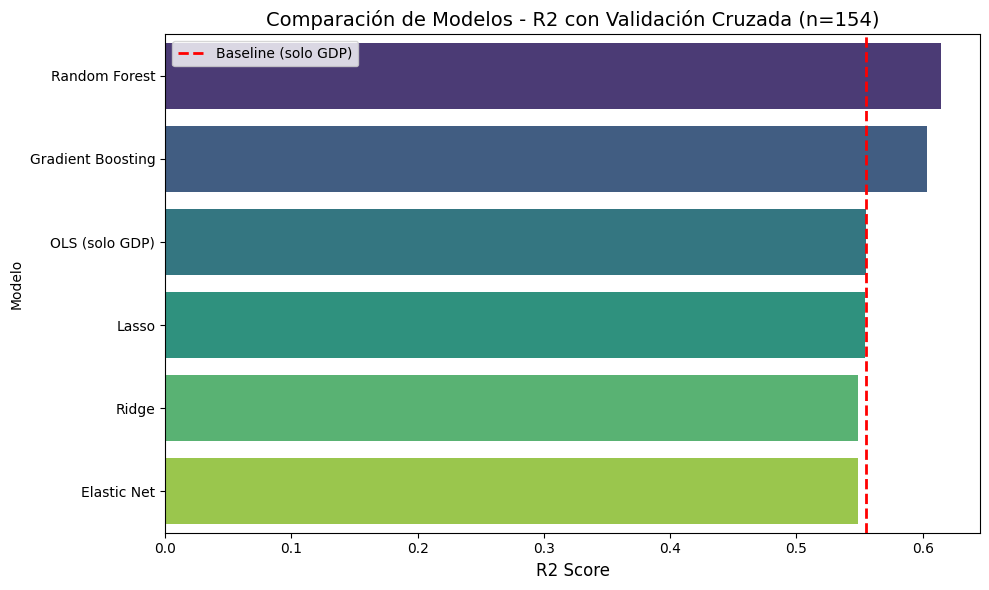

In [47]:
X = df_cervix[["log_GDP", "RT"]]
y = df_cervix["ASR"]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge con búsqueda automática de alpha
alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_scaled, y)

print(f"Mejor alpha: {ridge.alpha_:.3f}")
print(f"R2 (CV): {cross_val_score(ridge, X_scaled, y, cv=5, scoring='r2').mean():.3f}")


# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
resultados = {}

# 1. OLS baseline (solo log_GDP)
X_baseline = df_cervix[['log_GDP']]
y = df_cervix['ASR']


ols_baseline = LinearRegression()
scores_ols = cross_val_score(ols_baseline, X_baseline, y, cv=cv, scoring='r2')
resultados['OLS (solo GDP)'] = scores_ols.mean()

# 2. Ridge
X_scaled = scaler.fit_transform(X)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
scores_ridge = cross_val_score(ridge, X_scaled, y, cv=cv, scoring='r2')
resultados['Ridge'] = scores_ridge.mean()

# 3. Lasso
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
scores_lasso = cross_val_score(lasso, X_scaled, y, cv=cv, scoring='r2')
resultados['Lasso'] = scores_lasso.mean()

# 4. Elastic Net
elastic = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[0.3, 0.5, 0.7], cv=5, max_iter=10000)
scores_elastic = cross_val_score(elastic, X_scaled, y, cv=cv, scoring='r2')
resultados['Elastic Net'] = scores_elastic.mean()

# 5. Random Forest (limitado)
rf = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=10,
                           min_samples_leaf=5, random_state=42)

scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='r2')
resultados['Random Forest'] = scores_rf.mean()

# 6. Gradient Boosting (conservador)
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                               min_samples_split=10, min_samples_leaf=5, random_state=42)
scores_gb = cross_val_score(gb, X, y, cv=cv, scoring='r2')
resultados['Gradient Boosting'] = scores_gb.mean()

# Crear dataframe de resultados
df_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'R2_CV': list(resultados.values()) # Renamed column to 'R2_CV'
}).sort_values('R2_CV', ascending=False)

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(df_resultados.to_string(index=False))
print("="*50)

# Visualizar


plt.figure(figsize=(10, 6))
sns.barplot(data=df_resultados, y='Modelo', x='R2_CV', hue='Modelo', palette='viridis', legend=False) # Updated 'x' to 'R2_CV'
plt.title('Comparación de Modelos - R2 con Validación Cruzada (n=154)', fontsize=14)
plt.xlabel('R2 Score', fontsize=12)
plt.axvline(x=resultados['OLS (solo GDP)'], color='red', linestyle='--',
            label='Baseline (solo GDP)', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

En este caso, los modelos predictores que mejor se comportan usando ambas variables con respecto a la que usa una sola, serían Random Forest y GB, ambos hay que utilizarlos con mucha cautela debido al limitado tamaño muestral y outliers, y así evitar los sobreajustes.

# Random forest:

RANDOM FOREST - EVALUACIÓN COMPLETA

 MÉTRICAS DE AJUSTE:
----------------------------------------------------------------------
Métrica              Train           CV (5-fold)     Gap/Ratio
----------------------------------------------------------------------
R²                   0.7528          0.6162          0.1367
MAE                  0.9077          1.1268          1.24x
RMSE                 1.3427          1.6350          1.22x
OOB R²               0.6169         

 COMPARACIÓN CON VARIABILIDAD:
----------------------------------------------------------------------
Desviación Estándar ASR:  2.7089
RMSE / SD:                60.36%
MAE / SD:                 41.60%

 IMPORTANCIA DE VARIABLES:
----------------------------------------------------------------------
Variable  Importancia  Importancia_%
 log_GDP     0.589858      58.985774
      RT     0.410142      41.014226


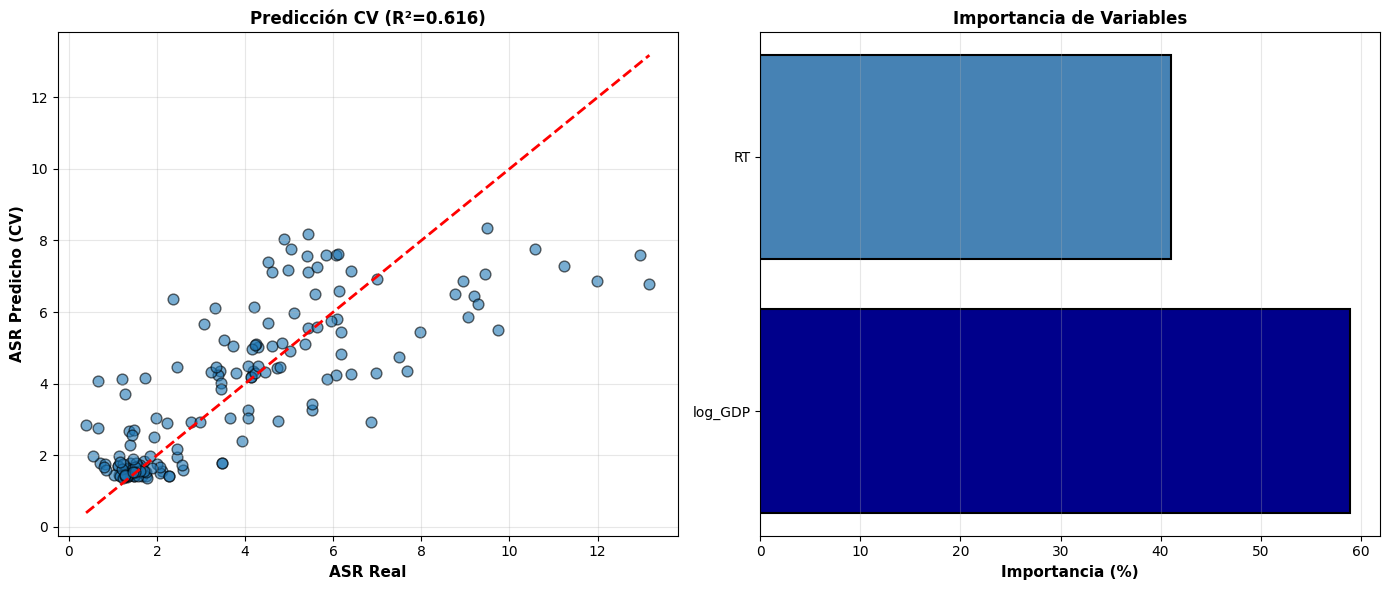

In [48]:
# Preparar los datos
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
std_asr = y.std()


# Configurar un modelo Random Forest con hiperparámetros para prevenir overfitting
rf_model_1 = RandomForestRegressor(
    n_estimators=50,          # Un número moderado de árboles
    max_depth=4,              # Limitar la profundidad de cada árbol
    min_samples_leaf=5,       # Mínimo de 5 muestras por hoja
    min_samples_split=10,     # Mínimo de 10 muestras para dividir un nodo
    max_features=0.7,         # Considerar el 70% de las características en cada split (o 'sqrt', 'log2')
    random_state=42,
    oob_score=True            # Calcular el R^2 Out-of-Bag (bueno para evaluar sin CV explícita)
)


# MÉTRICAS DE AJUSTE Y VALIDACIÓN CRUZADA      #

print("="*70)
print("RANDOM FOREST - EVALUACIÓN COMPLETA")
print("="*70)

# Validar el modelo usando validación cruzada (KFold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv_scores = cross_val_score(rf_model_1, X, y, cv=cv, scoring='r2')
mae_cv_scores = -cross_val_score(rf_model_1, X, y, cv=cv, scoring='neg_mean_absolute_error')
rmse_cv_scores = -cross_val_score(rf_model_1, X, y, cv=cv, scoring='neg_root_mean_squared_error')

r2_cv = r2_cv_scores.mean()
mae_cv = mae_cv_scores.mean()
rmse_cv = rmse_cv_scores.mean()

# Entrenar el modelo con todos los datos para obtener métricas de entrenamiento y OOB
rf_model_1.fit(X, y)
y_pred_train = rf_model_1.predict(X)
r2_train = r2_score(y, y_pred_train)
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

# Gap de overfitting
gap = r2_train - r2_cv

# Imprimir métricas
print("\n MÉTRICAS DE AJUSTE:")
print("-"*70)
print(f"{'Métrica':<20} {'Train':<15} {'CV (5-fold)':<15} {'Gap/Ratio'}")
print("-"*70)
print(f"{'R²':<20} {r2_train:<15.4f} {r2_cv:<15.4f} {gap:.4f}")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_cv:<15.4f} {mae_cv/mae_train:.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_cv:<15.4f} {rmse_cv/rmse_train:.2f}x")
print(f"{'OOB R²':<20} {rf_model_1.oob_score_:<15.4f}")
print("="*70)

print("\n COMPARACIÓN CON VARIABILIDAD:")
print("-"*70)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print(f"RMSE / SD:                {rmse_cv/std_asr:.2%}")
print(f"MAE / SD:                 {mae_cv/std_asr:.2%}")
print("="*70)


# IMPORTANCIA DE VARIABLES                     #

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model_1.feature_importances_,
    'Importancia_%': rf_model_1.feature_importances_ * 100
}).sort_values('Importancia', ascending=False)

print("\n IMPORTANCIA DE VARIABLES:")
print("-"*70)
print(importancia.to_string(index=False))
print("="*70)


# GRÁFICOS DE EVALUACIÓN                       #

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicho vs Real (CV) usando cross_val_predict para una vista más honesta
y_pred_cv_plot = cross_val_predict(rf_model_1, X, y, cv=cv)
axes[0].scatter(y, y_pred_cv_plot, alpha=0.6, edgecolors='k', s=60)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('ASR Real', fontweight='bold', fontsize=11)
axes[0].set_ylabel('ASR Predicho (CV)', fontweight='bold', fontsize=11)
axes[0].set_title(f'Predicción CV (R²={r2_cv:.3f})', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Importancia de variables
axes[1].barh(importancia['Variable'], importancia['Importancia_%'],
               color=['darkblue', 'steelblue'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Importancia (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Importancia de Variables', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Se intenta mejorar el modelo para no tener tanto sobreajuste

RANDOM FOREST - EVALUACIÓN COMPLETA

MÉTRICAS DE AJUSTE:
----------------------------------------------------------------------
Métrica              Train           CV (5-fold)     Gap/Ratio
----------------------------------------------------------------------
R²                   0.6993          0.6049          0.0944
MAE                  1.0094          1.1590          1.15x
RMSE                 1.4808          1.6604          1.12x
OOB R²               0.6214         

COMPARACIÓN CON VARIABILIDAD:
----------------------------------------------------------------------
Desviación Estándar ASR:  2.7089
RMSE / SD:                61.29%
MAE / SD:                 42.79%

EVALUACIÓN DE OVERFITTING:
----------------------------------------------------------------------
Gap (R² Train - R² CV):   0.0944

IMPORTANCIA DE VARIABLES:
----------------------------------------------------------------------
Variable  Importancia  Importancia_%
 log_GDP      0.58248      58.248047
      RT      0.41

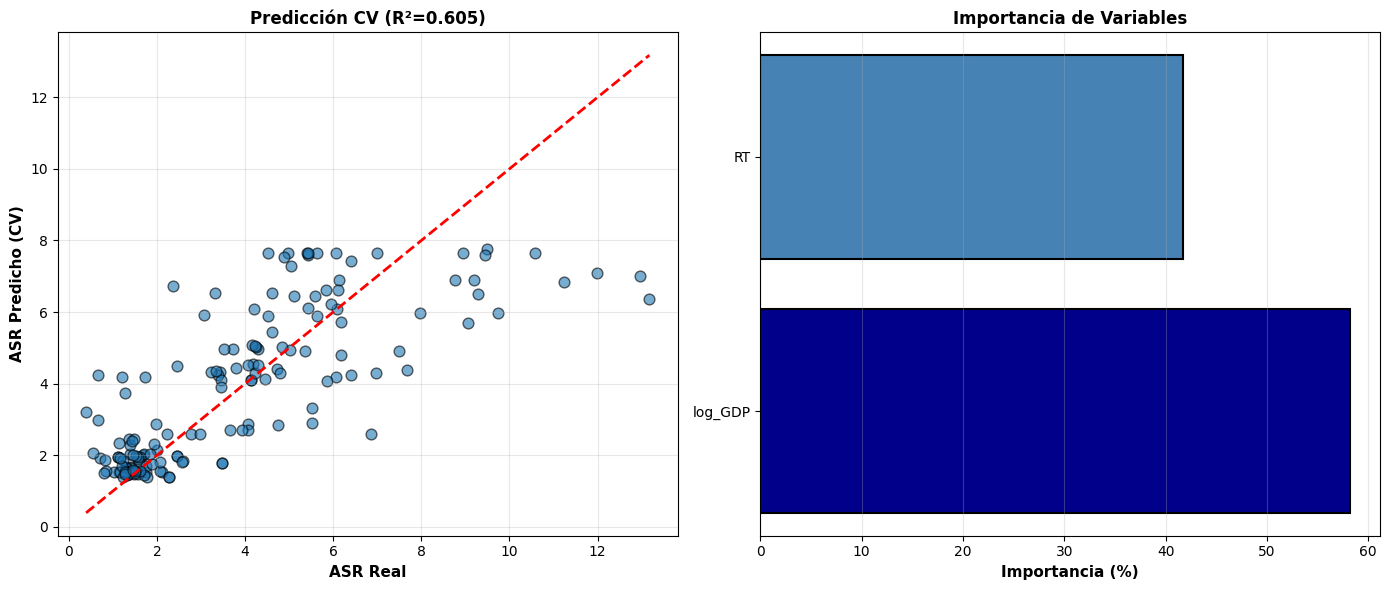

In [49]:

# Preparar los datos
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
std_asr = y.std()

# Configurar un modelo Random Forest con hiperparámetros para prevenir overfitting
rf_model = RandomForestRegressor(
    n_estimators=30,          # Un número moderado de árboles
    max_depth=3,              # Limitar la profundidad de cada árbol
    min_samples_leaf=10,       # Mínimo de muestras por hoja
    min_samples_split=20,     # Mínimo de muestras para dividir un nodo
    max_features=0.6,
    random_state=42,
    oob_score=True            # Calcular el R^2 Out-of-Bag
)


# MÉTRICAS DE AJUSTE Y VALIDACIÓN CRUZADA      #

print("="*70)
print("RANDOM FOREST - EVALUACIÓN COMPLETA")
print("="*70)

# Validar el modelo usando validación cruzada (KFold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='r2')
mae_cv_scores = -cross_val_score(rf_model, X, y, cv=cv, scoring='neg_mean_absolute_error')
rmse_cv_scores = -cross_val_score(rf_model, X, y, cv=cv, scoring='neg_root_mean_squared_error')

r2_cv = r2_cv_scores.mean()
mae_cv = mae_cv_scores.mean()
rmse_cv = rmse_cv_scores.mean()

# Entrenar el modelo con todos los datos para obtener métricas de entrenamiento y OOB
rf_model.fit(X, y)
y_pred_train = rf_model.predict(X)
r2_train = r2_score(y, y_pred_train)
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

# Gap de overfitting
gap = r2_train - r2_cv

# Imprimir métricas
print("\nMÉTRICAS DE AJUSTE:")
print("-"*70)
print(f"{'Métrica':<20} {'Train':<15} {'CV (5-fold)':<15} {'Gap/Ratio'}")
print("-"*70)
print(f"{'R²':<20} {r2_train:<15.4f} {r2_cv:<15.4f} {gap:.4f}")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_cv:<15.4f} {mae_cv/mae_train:.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_cv:<15.4f} {rmse_cv/rmse_train:.2f}x")
print(f"{'OOB R²':<20} {rf_model.oob_score_:<15.4f}")
print("="*70)

print("\nCOMPARACIÓN CON VARIABILIDAD:")
print("-"*70)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print(f"RMSE / SD:                {rmse_cv/std_asr:.2%}")
print(f"MAE / SD:                 {mae_cv/std_asr:.2%}")
print("="*70)

print("\nEVALUACIÓN DE OVERFITTING:")
print("-"*70)
print(f"Gap (R² Train - R² CV):   {gap:.4f}")


# IMPORTANCIA DE VARIABLES                     #

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': rf_model.feature_importances_,
    'Importancia_%': rf_model.feature_importances_ * 100
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE VARIABLES:")
print("-"*70)
print(importancia.to_string(index=False))
print("="*70)


# GRÁFICOS DE EVALUACIÓN                       #

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicho vs Real (CV) usando cross_val_predict para una vista más honesta
y_pred_cv_plot = cross_val_predict(rf_model, X, y, cv=cv)
axes[0].scatter(y, y_pred_cv_plot, alpha=0.6, edgecolors='k', s=60)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('ASR Real', fontweight='bold', fontsize=11)
axes[0].set_ylabel('ASR Predicho (CV)', fontweight='bold', fontsize=11)
axes[0].set_title(f'Predicción CV (R²={r2_cv:.3f})', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Importancia de variables
axes[1].barh(importancia['Variable'], importancia['Importancia_%'],
               color=['darkblue', 'steelblue'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Importancia (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Importancia de Variables', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Con este modelo se puede ver que ha mejorado el sobreajuste. En las métricas de ajuste se captura ~60% de la variación en ASR, el 40% restante puede deberse a otros factores como screening, tabaquismo, vacuación VPH, etc.

El modelo se equivoca 1.16 muertes/100k, con un 42.79% de errores, esto en análisis epidemiologico es aceptable.
Los 1.66 muertes/100k indicando que el modelo reduce la incertidumbre en casi un 40%.
El GAP muestra una buena generalización, siendo ese "hueco" el 9.44%.
En resumen, el modelo generaliza bien los datos nuevos, bajo riesgo de sobre ajuste y las predicciones son confiables.
El OOB del 62.14% es similar al de CV confirmando estabilidad y el ratio RMSE Train/CV es muy cercano a uno.
La contribución de este modelo dice que el PIB es el predictor mas importante, pero RT tiene un efecto sustancial del 42%, por lo tanto, RT reduce la mortalidad independientemente del nivel economico.
El modelo Random Forest presenta la mejor capacidad predictiva entre los enfoques evaluados, manteniendo estabilidad en validación cruzada y validación OOB. No obstante, la mejora frente a modelos lineales es moderada, lo que sugiere que la relación entre mortalidad por cáncer de cérvix, nivel económico y disponibilidad de radioterapia está dominada por efectos estructurales de baja complejidad. La importancia relativa de la variable RT indica que la disponibilidad de radioterapia aporta información relevante adicional al nivel de renta.
En resumen, *El modelo predice correctamente 6 de cada 10 casos de mortalidad por cáncer cervical, con un margen de error promedio de 1.2 muertes por 100,000 habitantes. Los resultados confirman que:*
1. **El PIB explica el 58% del efecto** (países ricos tienen mejor salud general)
2. **La radioterapia explica el 42% del efecto** (infraestructura específica salva vidas)
3. **El modelo es confiable:** funciona igual de bien con datos nuevos (bajo sobreajuste)

##Gradient Boosting
Ahora, procedemos a verificar con GB

GRADIENT BOOSTING - EVALUACIÓN COMPLETA

MÉTRICAS DE AJUSTE:
----------------------------------------------------------------------
Métrica              Train           CV (5-fold)     Gap/Ratio
----------------------------------------------------------------------
R²                   0.7586          0.6033          0.1552
MAE                  0.9303          1.1493          1.24x
RMSE                 1.3270          1.6586          1.25x

COMPARACIÓN CON VARIABILIDAD:
----------------------------------------------------------------------
Desviación Estándar ASR:  2.7089
RMSE / SD:                61.23%
MAE / SD:                 42.43%

EVALUACIÓN DE OVERFITTING:
----------------------------------------------------------------------
Gap (R² Train - R² CV):   0.1552

IMPORTANCIA DE VARIABLES:
----------------------------------------------------------------------
Variable  Importancia  Importancia_%
 log_GDP     0.863798      86.379807
      RT     0.136202      13.620193


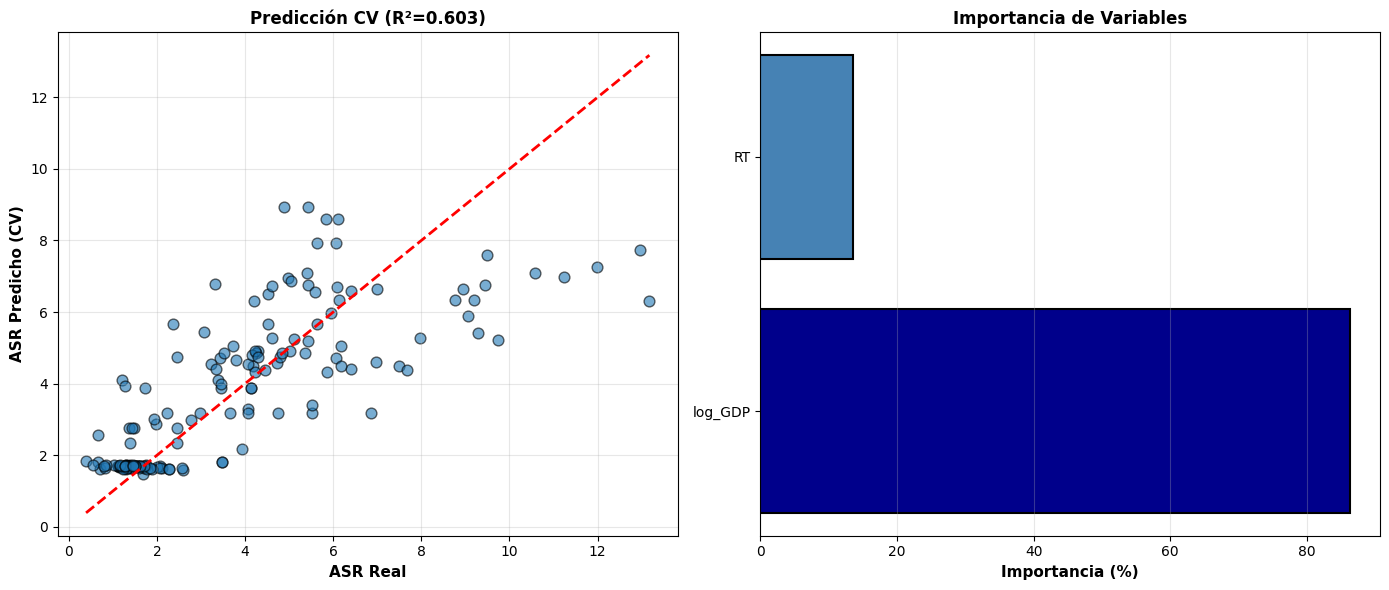

In [50]:
X_RT = df_cervix[["log_GDP", "RT"]]
y = df_cervix["ASR"]
X = X_RT
# Entrenar el modelo
gb = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_RT, y)

# MÉTRICAS DE AJUSTE Y VALIDACIÓN CRUZADA      #

print("="*70)
print("GRADIENT BOOSTING - EVALUACIÓN COMPLETA")
print("="*70)

# Validar el modelo usando validación cruzada (KFold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv_scores = cross_val_score(gb, X, y, cv=cv, scoring='r2')
mae_cv_scores = -cross_val_score(gb, X, y, cv=cv, scoring='neg_mean_absolute_error')
rmse_cv_scores = -cross_val_score(gb, X, y, cv=cv, scoring='neg_root_mean_squared_error')

r2_cv = r2_cv_scores.mean()
mae_cv = mae_cv_scores.mean()
rmse_cv = rmse_cv_scores.mean()

# Entrenar el modelo con todos los datos para obtener métricas de entrenamiento
gb.fit(X, y)
y_pred_train = gb.predict(X)
r2_train = r2_score(y, y_pred_train)
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

# Gap de overfitting
gap = r2_train - r2_cv

# Imprimir métricas
print("\nMÉTRICAS DE AJUSTE:")
print("-"*70)
print(f"{'Métrica':<20} {'Train':<15} {'CV (5-fold)':<15} {'Gap/Ratio'}")
print("-"*70)
print(f"{'R²':<20} {r2_train:<15.4f} {r2_cv:<15.4f} {gap:.4f}")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_cv:<15.4f} {mae_cv/mae_train:.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_cv:<15.4f} {rmse_cv/rmse_train:.2f}x")
#print(f"{'OOB R²':<20} {gb.oob_score_:<15.4f}")
print("="*70)

print("\nCOMPARACIÓN CON VARIABILIDAD:")
print("-"*70)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print(f"RMSE / SD:                {rmse_cv/std_asr:.2%}")
print(f"MAE / SD:                 {mae_cv/std_asr:.2%}")
print("="*70)

print("\nEVALUACIÓN DE OVERFITTING:")
print("-"*70)
print(f"Gap (R² Train - R² CV):   {gap:.4f}")


# IMPORTANCIA DE VARIABLES                     #

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb.feature_importances_,
    'Importancia_%': gb.feature_importances_ * 100
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE VARIABLES:")
print("-"*70)
print(importancia.to_string(index=False))
print("="*70)


# GRÁFICOS DE EVALUACIÓN                       #

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicho vs Real (CV) usando cross_val_predict para una vista más honesta
y_pred_cv_plot = cross_val_predict(gb, X, y, cv=cv)
axes[0].scatter(y, y_pred_cv_plot, alpha=0.6, edgecolors='k', s=60)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('ASR Real', fontweight='bold', fontsize=11)
axes[0].set_ylabel('ASR Predicho (CV)', fontweight='bold', fontsize=11)
axes[0].set_title(f'Predicción CV (R²={r2_cv:.3f})', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Importancia de variables
axes[1].barh(importancia['Variable'], importancia['Importancia_%'],
               color=['darkblue', 'steelblue'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Importancia (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Importancia de Variables', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

EVALUACIÓN COMPLETA

MÉTRICAS DE AJUSTE:
----------------------------------------------------------------------
Métrica              Train           CV (5-fold)     Gap/Ratio
----------------------------------------------------------------------
R²                   0.5747          0.5186          0.0562
MAE                  1.2518          1.3181          1.05x
RMSE                 1.7611          1.8392          1.04x

COMPARACIÓN CON VARIABILIDAD:
----------------------------------------------------------------------
Desviación Estándar ASR:  2.7089
RMSE / SD:                67.90%
MAE / SD:                 48.66%

EVALUACIÓN DE OVERFITTING:
----------------------------------------------------------------------
Gap (R² Train - R² CV):   0.0562

IMPORTANCIA DE VARIABLES:
----------------------------------------------------------------------
Variable  Importancia  Importancia_%
 log_GDP     0.812376      81.237597
      RT     0.187624      18.762403


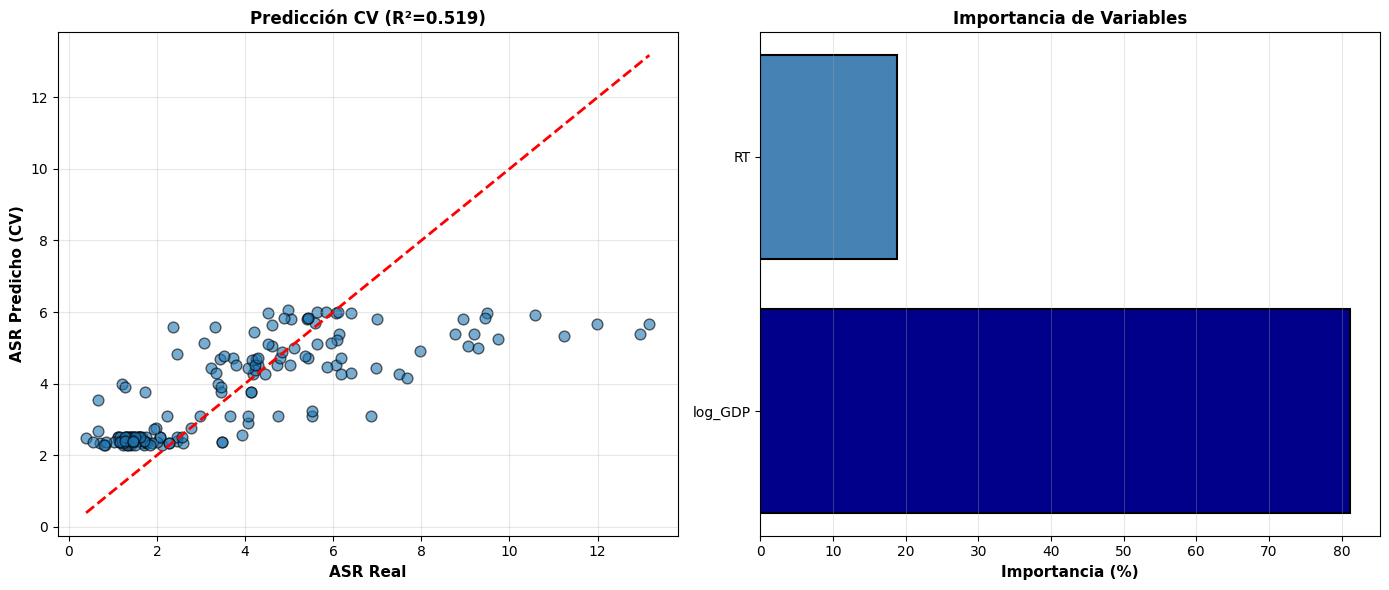

In [51]:

X_RT = df_cervix[["log_GDP", "RT"]]
y = df_cervix["ASR"]
X = X_RT
# Modelo (menos overfitting)
gb_simple = GradientBoostingRegressor(
    n_estimators=40,         # Menos árboles (era 40)
    learning_rate=0.03,      # Más conservador (era 0.03)
    max_depth=1,             # Árboles más simples (era 1), corregido a entero
    min_samples_split=15,    # Más restrictivo (era 15)
    min_samples_leaf=8,     # Más restrictivo (era 8)
    subsample=0.8,           # Añadir randomización (0.8)
    random_state=42
)




gb_simple.fit(X_RT, y)

# MÉTRICAS DE AJUSTE Y VALIDACIÓN CRUZADA      #

print("="*70)
print("EVALUACIÓN COMPLETA")
print("="*70)

# Validar el modelo usando validación cruzada (KFold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_cv_scores = cross_val_score(gb_simple, X, y, cv=cv, scoring='r2')
mae_cv_scores = -cross_val_score(gb_simple, X, y, cv=cv, scoring='neg_mean_absolute_error')
rmse_cv_scores = -cross_val_score(gb_simple, X, y, cv=cv, scoring='neg_root_mean_squared_error')

r2_cv = r2_cv_scores.mean()
mae_cv = mae_cv_scores.mean()
rmse_cv = rmse_cv_scores.mean()

# Entrenar el modelo con todos los datos para obtener métricas de entrenamiento
gb_simple.fit(X, y)
y_pred_train = gb_simple.predict(X)
r2_train = r2_score(y, y_pred_train)
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

# Gap de overfitting
gap = r2_train - r2_cv

# Imprimir métricas
print("\nMÉTRICAS DE AJUSTE:")
print("-"*70)
print(f"{'Métrica':<20} {'Train':<15} {'CV (5-fold)':<15} {'Gap/Ratio'}")
print("-"*70)
print(f"{'R²':<20} {r2_train:<15.4f} {r2_cv:<15.4f} {gap:.4f}")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_cv:<15.4f} {mae_cv/mae_train:.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_cv:<15.4f} {rmse_cv/rmse_train:.2f}x")
#print(f"{'OOB R²':<20} {gb.oob_score_:<15.4f}")
print("="*70)

print("\nCOMPARACIÓN CON VARIABILIDAD:")
print("-"*70)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print(f"RMSE / SD:                {rmse_cv/std_asr:.2%}")
print(f"MAE / SD:                 {mae_cv/std_asr:.2%}")
print("="*70)

print("\nEVALUACIÓN DE OVERFITTING:")
print("-"*70)
print(f"Gap (R² Train - R² CV):   {gap:.4f}")


# IMPORTANCIA DE VARIABLES                     #

importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb_simple.feature_importances_,
    'Importancia_%': gb_simple.feature_importances_ * 100
}).sort_values('Importancia', ascending=False)

print("\nIMPORTANCIA DE VARIABLES:")
print("-"*70)
print(importancia.to_string(index=False))
print("="*70)


# GRÁFICOS DE EVALUACIÓN                       #

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Predicho vs Real (CV) usando cross_val_predict para una vista más honesta
y_pred_cv_plot = cross_val_predict(gb_simple, X, y, cv=cv)
axes[0].scatter(y, y_pred_cv_plot, alpha=0.6, edgecolors='k', s=60)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('ASR Real', fontweight='bold', fontsize=11)
axes[0].set_ylabel('ASR Predicho (CV)', fontweight='bold', fontsize=11)
axes[0].set_title(f'Predicción CV (R²={r2_cv:.3f})', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Importancia de variables
axes[1].barh(importancia['Variable'], importancia['Importancia_%'],
               color=['darkblue', 'steelblue'], edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Importancia (%)', fontweight='bold', fontsize=11)
axes[1].set_title('Importancia de Variables', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

En este caso, a pesar que en todos los modelos, durante la predicción se satura y llega a un umbral que en este caso es hasta 6, en cambio, con los otros modelos, sucede cuando la tasa de mortaldad llega al 8, siendo los otros más realistas, esto es como se sabe, a lor outliers.

La tabla resumen

In [52]:
# 1) MÉTRICAS DE AJUSTE
metrics = pd.DataFrame({
    'RF Train':     [0.6993, 1.0094, 1.4808, 0.6214],
    'RF CV':        [0.6049, 1.1590, 1.6604,    None],
    'RF Gap/Ratio': [0.0944, '1.15x', '1.12x',   None],
    'GB Train':     [0.5747, 1.2518, 1.7611,    None],
    'GB CV':        [0.5186, 1.3181, 1.8392,    None],
    'GB Gap/Ratio': [0.0562, '1.05x', '1.04x',   None]
}, index=['R²', 'MAE', 'RMSE', 'OOB R²'])
print(metrics)


# 2) COMPARACIÓN CON LA VARIABILIDAD
variability = pd.DataFrame({
    'RMSE / SD RF': ['61.29%'],
    'RMSE / SD GB': ['67.90%'],
    'MAE / SD RF':  ['42.79%'],
    'MAE / SD GB':  ['48.66%']
}, index=[f'Desviación Estándar ASR = 2.7089'])
print(variability)

# 3) IMPORTANCIA DE VARIABLES
importance = pd.DataFrame({
    'RF Importancia_%': [58.248047, 41.751953],
    'GB Importancia_%': [81.237597, 18.762403]
}, index=['log_GDP', 'RT'])
print(importance)

        RF Train   RF CV RF Gap/Ratio  GB Train   GB CV GB Gap/Ratio
R²        0.6993  0.6049       0.0944    0.5747  0.5186       0.0562
MAE       1.0094  1.1590        1.15x    1.2518  1.3181        1.05x
RMSE      1.4808  1.6604        1.12x    1.7611  1.8392        1.04x
OOB R²    0.6214     NaN         None       NaN     NaN         None
                                 RMSE / SD RF RMSE / SD GB MAE / SD RF  \
Desviación Estándar ASR = 2.7089       61.29%       67.90%      42.79%   

                                 MAE / SD GB  
Desviación Estándar ASR = 2.7089      48.66%  
         RF Importancia_%  GB Importancia_%
log_GDP         58.248047         81.237597
RT              41.751953         18.762403


Con respecto a R2, RF es significativamente más alto, sugiriendo que se ajusta mejor a los datos con los que fue entrenado, en la validación cruzada también muestra un mejor rendimiento predictivo aunque caiga un poco, algo que es habitual, con respecto al sobreajuste, GB tiene menor GAP siendo menos propenso.
En los errores, RF tiene un MAE de CV más bajo, lo que significa que en promedio, sus predicciones están mas cerca a las reales. Con respecto a la penalización de errores, RF confirma su mayor precisión. Y para el R2 de OOB,. solamente se puede evaluar con RF, es muy cercano al de CV, demostrando su robustez y consistencia y que no hay un sobreajuste severo. Asimismo con la variabilidad, es ligeramente más bajo en RF, demostrando ser mas eficaz en reducir incertidumbre.
*Importancia de las variables* en este punto, ambos modelos identifican el PIB como la variable más importante, sin embargo, hay una diferencia notable en la relativa al RT, RF encuentra más interaciones o un atrón más complejo donde RT juega un papel mas relevante.

En resumen, Random Forest es el modelo con mejor rendimiento general, representa mayor variabilidad, menor errores y mayor capacidad predictiva, auqneu Gradient Boosting presenta menor GAP, su rendimiento predictivo es inferior, siendo entonces RF la elecció más sólida.

Ahora con el modelo ganador, se busca las dependencias  parciales, analisis de residuos y árboles de decisiones.

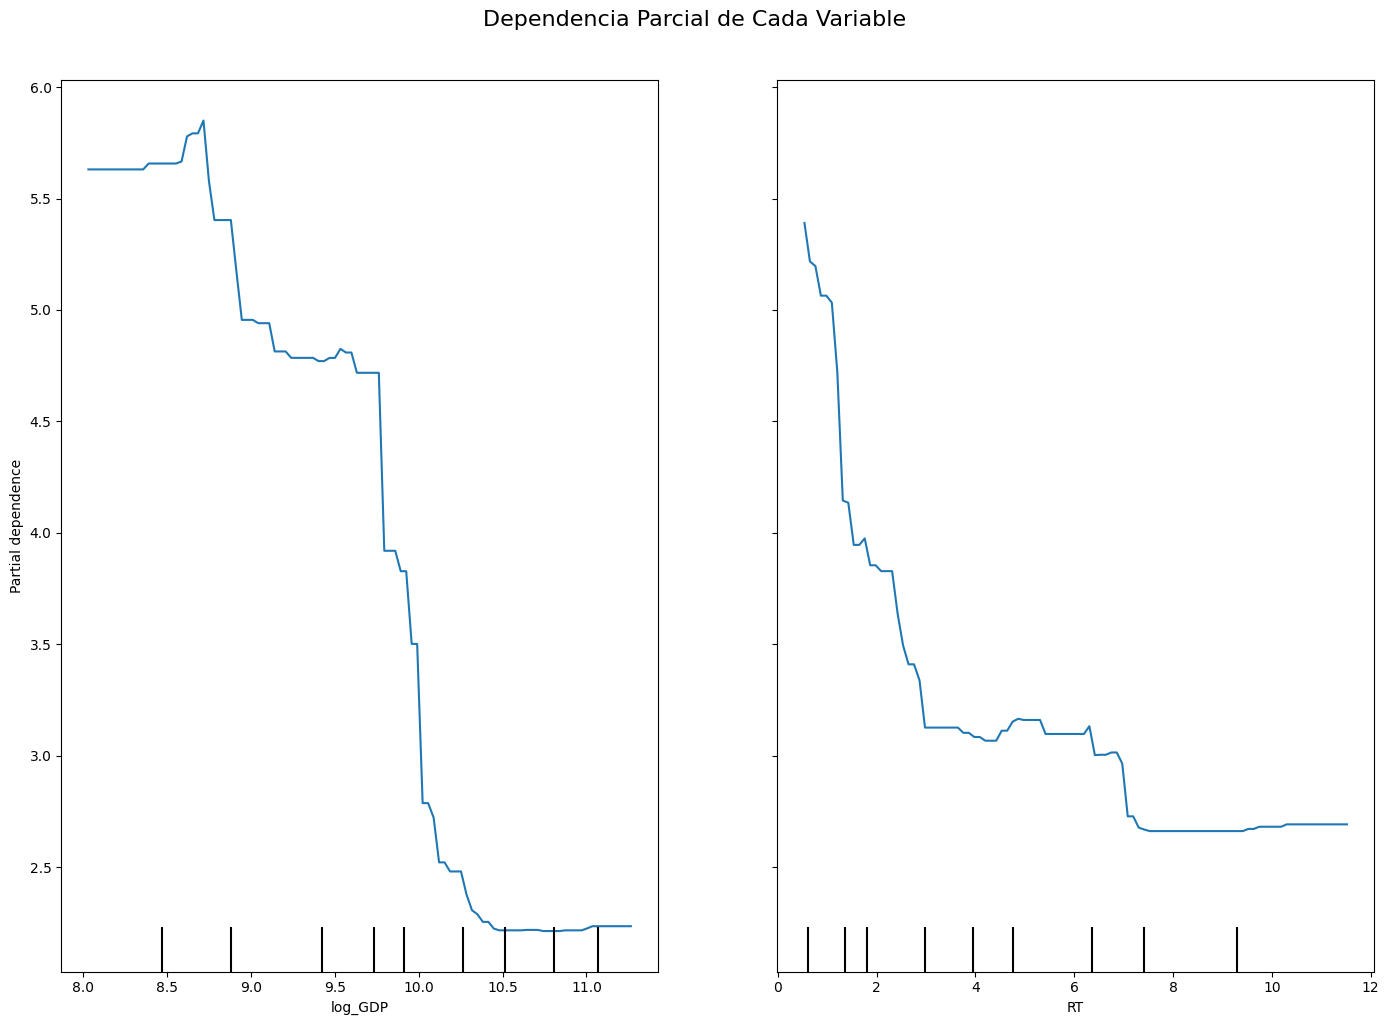

In [53]:
# Ver cómo cada variable afecta la predicción
fig, ax = plt.subplots(figsize=(14, 10))
features_to_plot = list(range(len(X_RT.columns)))

PartialDependenceDisplay.from_estimator(
    rf_model,
    X_RT,
    features_to_plot,
    feature_names=X_RT.columns,
    ax=ax,
    n_cols=3
)
plt.suptitle('Dependencia Parcial de Cada Variable', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Con estos resultados, se tiene entonces que ambos llegan a cierto umbral de saturación, dondo despues de ese punto, ASR no es afectada.

Con respecto al RT, hay varios picos de saturación que bajan las pendientes de manera significativa, esto podría deberse a varios factores como por ejemplo, falta de personal a pesar de ls disponibilidad de equipos, disciplina de los pacientes a la hora de la constancia con el tratamiento, etc.


In [54]:
# Modelo baseline (solo log_GDP)

#Se decidió por rf_model, a partir de aquí, y_pred_gb=rf_model.predict(X_RT)
#X = df_cervix[["log_GDP"]]
y = df_cervix["ASR"]
y_pred_gb = rf_model.predict(X_RT)
X_baseline = df_cervix[['log_GDP']]
ols_baseline = LinearRegression()
ols_baseline.fit(X_baseline, y)
y_pred_baseline = ols_baseline.predict(X_baseline)

# Intervalos de confianza
residuos_baseline = y - y_pred_baseline
std_baseline = np.std(residuos_baseline)
intervalo_95_baseline = 1.96 * std_baseline

residuos_gb = y - y_pred_gb
std_gb = np.std(residuos_gb)
intervalo_95_gb = 1.96 * std_gb

print("="*60)
print("COMPARACIÓN DE INTERVALOS DE CONFIANZA")
print("="*60)
print(f"OLS Baseline:")
print(f"  Intervalo 95%: ±{intervalo_95_baseline:.2f}")
print(f"  Desv. estándar residuos: {std_baseline:.2f}")
print()
print(f"Gradient Boosting:")
print(f"  Intervalo 95%: ±{intervalo_95_gb:.2f}")
print(f"  Desv. estándar residuos: {std_gb:.2f}")
print()
print(f"Reducción de incertidumbre: {((std_baseline - std_gb) / std_baseline) * 100:.1f}%")
print("="*60)

COMPARACIÓN DE INTERVALOS DE CONFIANZA
OLS Baseline:
  Intervalo 95%: ±3.45
  Desv. estándar residuos: 1.76

Gradient Boosting:
  Intervalo 95%: ±2.90
  Desv. estándar residuos: 1.48

Reducción de incertidumbre: 15.9%


Presentando entonces una mejora del 15% con respecto al modelo base de una variable.

---



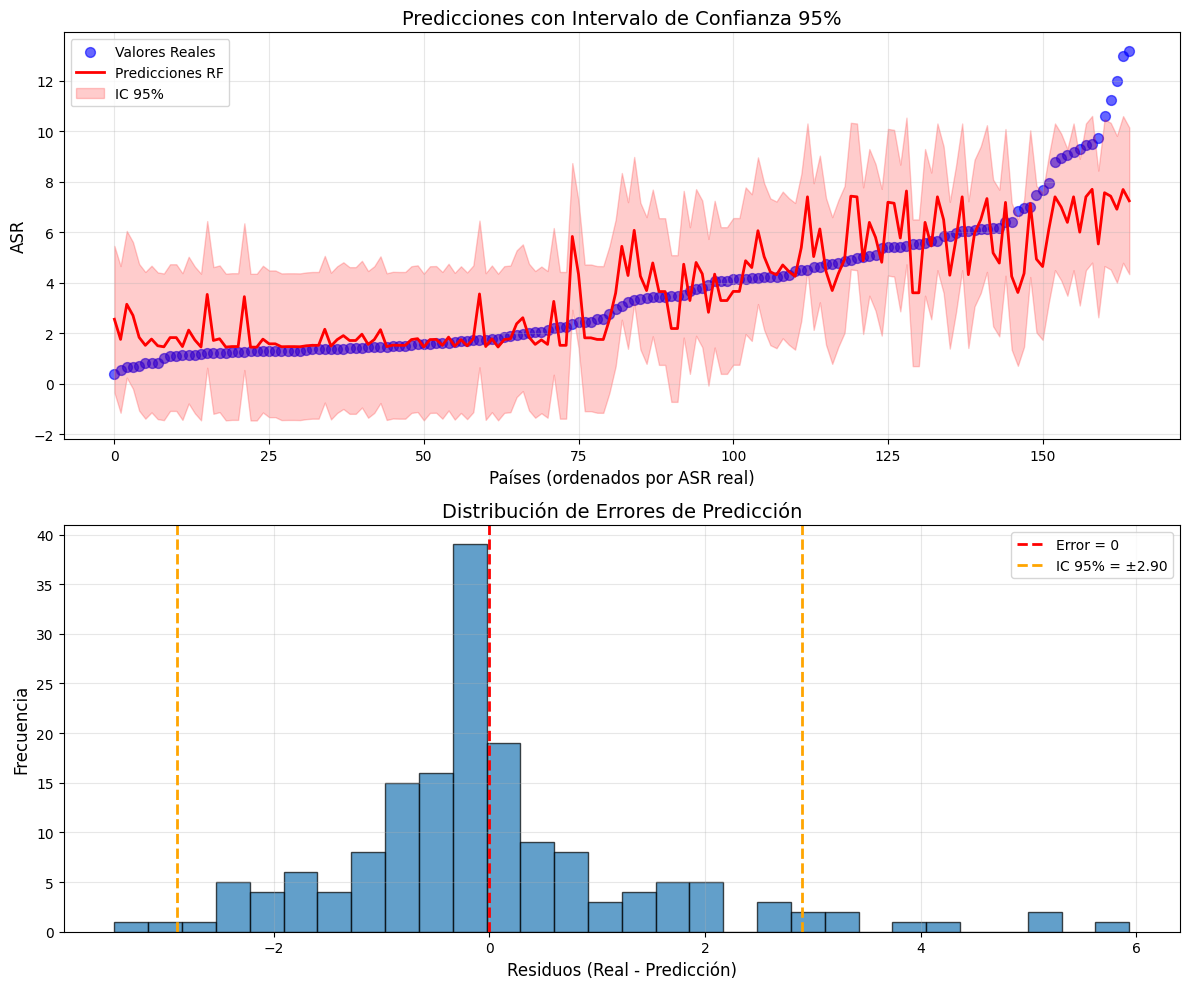

ANÁLISIS DE RESIDUOS
Media de residuos: 0.0141 (debería ser ≈0)
Mediana de residuos: -0.1609
MAE (Error Absoluto Medio): 1.01
RMSE (Raíz del Error Cuadrático Medio): 1.48

% de predicciones dentro de ±1 unidad: 65.5%
% de predicciones dentro de ±2 unidades: 84.2%
% de predicciones dentro de IC 95%: 93.9%


In [55]:
# Ordenar por valores reales para mejor visualización
orden = np.argsort(y)
y_ordenado = y.iloc[orden]
y_pred_ordenado = y_pred_gb[orden]

# Calcular intervalos
residuos = y - y_pred_gb
std_residuos = np.std(residuos)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Predicciones con intervalos de confianza
axes[0].scatter(range(len(y_ordenado)), y_ordenado,
                alpha=0.6, s=50, label='Valores Reales', color='blue')
axes[0].plot(range(len(y_pred_ordenado)), y_pred_ordenado,
             'r-', linewidth=2, label='Predicciones RF')
axes[0].fill_between(range(len(y_pred_ordenado)),
                      y_pred_ordenado - 1.96*std_residuos,
                      y_pred_ordenado + 1.96*std_residuos,
                      alpha=0.2, color='red', label='IC 95%')
axes[0].set_xlabel('Países (ordenados por ASR real)', fontsize=12)
axes[0].set_ylabel('ASR', fontsize=12)
axes[0].set_title('Predicciones con Intervalo de Confianza 95%', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Distribución de residuos
axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[1].axvline(x=1.96*std_residuos, color='orange', linestyle='--',
                linewidth=2, label=f'IC 95% = ±{1.96*std_residuos:.2f}')
axes[1].axvline(x=-1.96*std_residuos, color='orange', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos (Real - Predicción)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Errores de Predicción', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("="*60)
print("ANÁLISIS DE RESIDUOS")
print("="*60)
print(f"Media de residuos: {np.mean(residuos):.4f} (debería ser ≈0)")
print(f"Mediana de residuos: {np.median(residuos):.4f}")
print(f"MAE (Error Absoluto Medio): {np.mean(np.abs(residuos)):.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {np.sqrt(np.mean(residuos**2)):.2f}")
print()
print(f"% de predicciones dentro de ±1 unidad: {(np.abs(residuos) < 1).sum() / len(residuos) * 100:.1f}%")
print(f"% de predicciones dentro de ±2 unidades: {(np.abs(residuos) < 2).sum() / len(residuos) * 100:.1f}%")
print(f"% de predicciones dentro de IC 95%: {(np.abs(residuos) < 1.96*std_residuos).sum() / len(residuos) * 100:.1f}%")

La grafica de los residuos indica que la distribución de residuos es bastante centrada cercana a cero demostrando que es buena señal, las barras presentan una forma aproximada de campana, y los que están fuera del rango se podrían explicar por los outliers que se han visto en las graficas de caja y bigote.



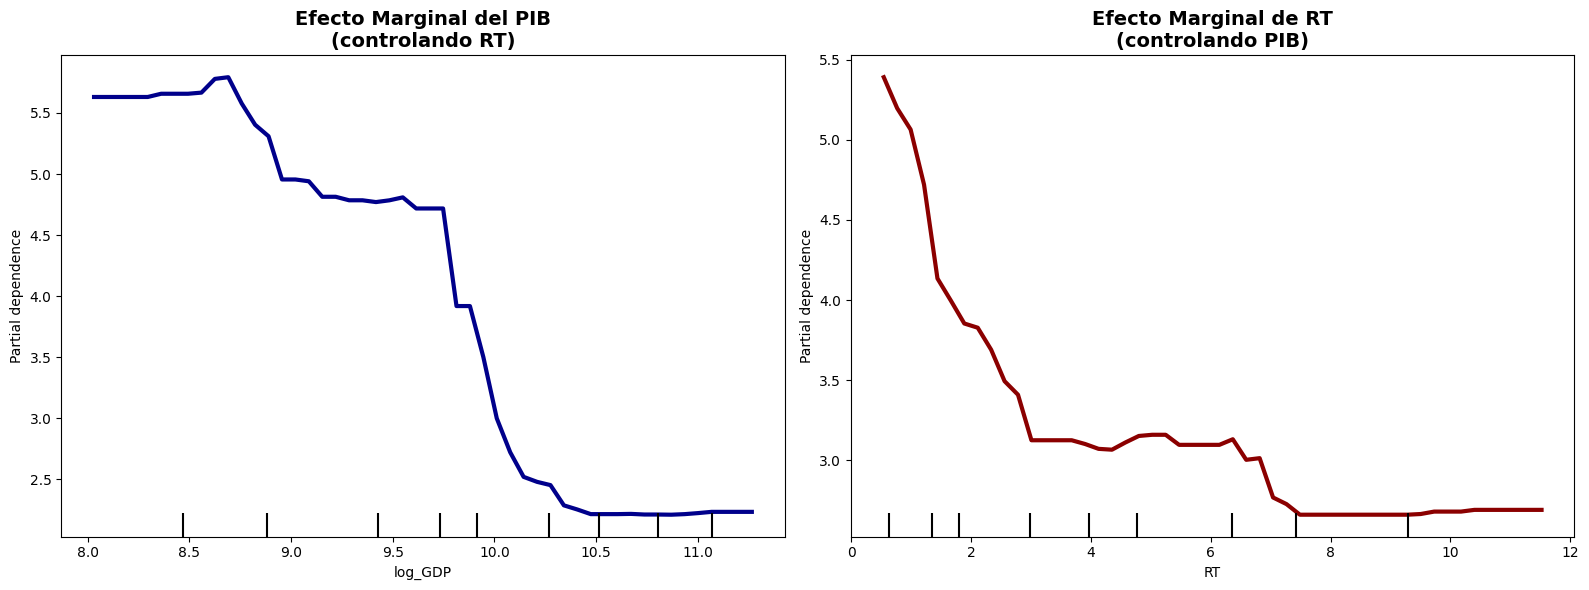

ANÁLISIS DEL EFECTO DE RT SOBRE MORTALIDAD

 RANGO DE RT EN DATOS:
   Mínimo: 0.54 equipos/millón
   Máximo: 11.52 equipos/millón

 EFECTO SOBRE ASR (controlando PIB):
   ASR con RT mínimo: 5.39 muertes/100k
   ASR con RT máximo: 2.69 muertes/100k
   Reducción total:   2.70 muertes/100k
   Reducción relativa: 50.1%

 Reducción con3 equipos/millón :2.26 muertes/100k
   Reducción relativa (RT minimo-3 RT): 41.89%

 UMBRAL DETECTADO:
   RT crítico: 1.44 equipos/millón
   → Máximo cambio de pendiente ocurre aquí

 EFECTO POR SEGMENTO:
   RT < 1.44: reduce 1.26 muertes/100k
   RT > 1.44: reduce 1.44 muertes/100k
   Ratio de efectos: 0.9x


In [56]:
rf = rf_model
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
rf.fit(X, y)

# ============================================
# GRÁFICO DE DEPENDENCIA PARCIAL
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Efecto de log_GDP
pdp_gdp = PartialDependenceDisplay.from_estimator(
    rf, X, features=[0],
    ax=axes[0],
    grid_resolution=50,
    line_kw={'color': 'darkblue', 'linewidth': 3}
)
axes[0].set_xlabel('log(PIB per cápita)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Efecto Parcial en ASR\n(muertes/100k)', fontweight='bold', fontsize=13)
axes[0].set_title('Efecto Marginal del PIB\n(controlando RT)',
                  fontweight='bold', fontsize=14)
axes[0].grid(alpha=0.3, linestyle='--')

# Plot 2: Efecto de RT (EL IMPORTANTE)
pdp_rt = PartialDependenceDisplay.from_estimator(
    rf, X, features=[1],
    ax=axes[1],
    grid_resolution=50,
    line_kw={'color': 'darkred', 'linewidth': 3}
)
axes[1].set_xlabel('RT (equipos/millón habitantes)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Efecto Parcial en ASR\n(muertes/100k)', fontweight='bold', fontsize=13)
axes[1].set_title('Efecto Marginal de RT\n(controlando PIB)',
                  fontweight='bold', fontsize=14)
axes[1].grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_partial_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# ANÁLISIS NUMÉRICO DEL EFECTO DE RT
# ============================================
pdp_result = partial_dependence(rf, X, features=[1], grid_resolution=50)
rt_values = pdp_result['grid_values'][0]
asr_effect = pdp_result['average'][0]

# Detectar umbral (máximo cambio de pendiente)
pendientes = np.diff(asr_effect) / np.diff(rt_values)
idx_max_cambio = np.argmax(np.abs(np.diff(pendientes)))
umbral_rt = rt_values[idx_max_cambio + 1]

# Calcular reducción de mortalidad
asr_min_rt = asr_effect[0]  # ASR con RT mínimo
asr_max_rt = asr_effect[-1]  # ASR con RT máximo
reduccion_total = asr_min_rt - asr_max_rt

# Interpolamos el ASR justo en RT = 3
rt_objetivo   = 3.0
asr_at_rt3    = np.interp(rt_objetivo, rt_values, asr_effect)

# Reducción de mortalidad (muertes/100k) al subir desde RT_mín a RT=3
reduccion_rt3 = asr_min_rt - asr_at_rt3

# Reducción relativa en %
reduccion_relativa = reduccion_rt3 / asr_min_rt * 100


print("="*70)
print("ANÁLISIS DEL EFECTO DE RT SOBRE MORTALIDAD")
print("="*70)
print(f"\n RANGO DE RT EN DATOS:")
print(f"   Mínimo: {rt_values[0]:.2f} equipos/millón")

print(f"   Máximo: {rt_values[-1]:.2f} equipos/millón")

print(f"\n EFECTO SOBRE ASR (controlando PIB):")
print(f"   ASR con RT mínimo: {asr_min_rt:.2f} muertes/100k")
print(f"   ASR con RT máximo: {asr_max_rt:.2f} muertes/100k")
print(f"   Reducción total:   {reduccion_total:.2f} muertes/100k")
print(f"   Reducción relativa: {(reduccion_total/asr_min_rt)*100:.1f}%")

print(f"\n Reducción con3 equipos/millón :{reduccion_rt3:.2f} muertes/100k")
print(f"   Reducción relativa (RT minimo-3 RT): {reduccion_relativa:.2f}%")

print(f"\n UMBRAL DETECTADO:")
print(f"   RT crítico: {umbral_rt:.2f} equipos/millón")
print(f"   → Máximo cambio de pendiente ocurre aquí")

# Efecto por segmento
idx_umbral = np.argmin(np.abs(rt_values - umbral_rt))
efecto_antes = asr_effect[0] - asr_effect[idx_umbral]
efecto_despues = asr_effect[idx_umbral] - asr_effect[-1]

print(f"\n EFECTO POR SEGMENTO:")
print(f"   RT < {umbral_rt:.2f}: reduce {efecto_antes:.2f} muertes/100k")
print(f"   RT > {umbral_rt:.2f}: reduce {efecto_despues:.2f} muertes/100k")
print(f"   Ratio de efectos: {efecto_antes/efecto_despues:.1f}x")

print("="*70)

Con estos resultados, se podría explicar el por que en los estandares internacionales, las recomendaciones de la disponibilidad de equipos de radioterapia oscilan entre 1 y 4 aceleradores para países con bajo-medio PIB per capita.

Si se aumenta de 1/2 RT/millon de habitantes a 3 RT/millón, se podría reducir un 40% aproximadamente de las muertes por cancer de cervix.

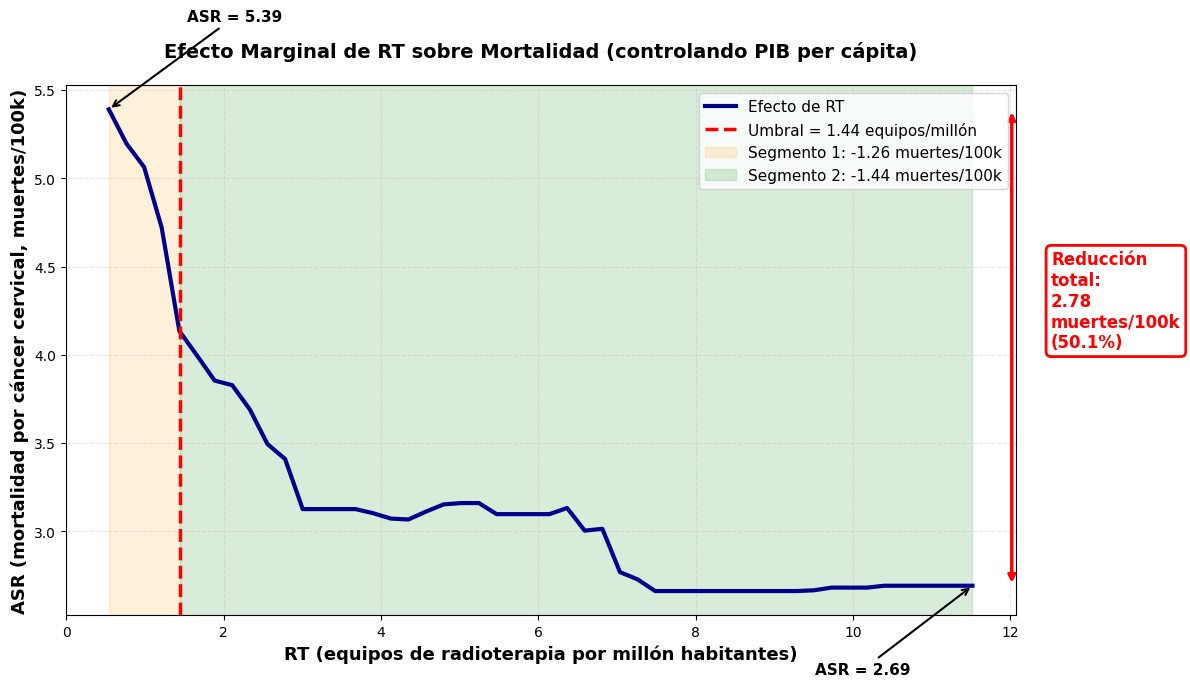

In [57]:


# Tu modelo RF

rf = rf_model
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
rf.fit(X, y)

# ============================================
# GRÁFICO DE DEPENDENCIA PARCIAL
# ============================================
pdp_result = partial_dependence(rf, X, features=[1], grid_resolution=50)
rt_values = pdp_result['grid_values'][0]
asr_effect = pdp_result['average'][0]

fig, ax = plt.subplots(figsize=(12, 7))

# Curva de efecto
ax.plot(rt_values, asr_effect, linewidth=3, color='darkblue', label='Efecto de RT')

# Marcar umbral
ax.axvline(1.44, color='red', linestyle='--', linewidth=2.5,
           label='Umbral = 1.44 equipos/millón', zorder=5)

# Áreas sombreadas
ax.axvspan(rt_values.min(), 1.44, alpha=0.15, color='orange',
           label='Segmento 1: -1.26 muertes/100k')
ax.axvspan(1.44, rt_values.max(), alpha=0.15, color='green',
           label='Segmento 2: -1.44 muertes/100k')

# Anotaciones
ax.annotate(f'ASR = {asr_effect[0]:.2f}',
            xy=(rt_values[0], asr_effect[0]),
            xytext=(rt_values[0] + 1, asr_effect[0] + 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, fontweight='bold')

ax.annotate(f'ASR = {asr_effect[-1]:.2f}',
            xy=(rt_values[-1], asr_effect[-1]),
            xytext=(rt_values[-1] - 2, asr_effect[-1] - 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=11, fontweight='bold')

# Reducción total
ax.annotate('', xy=(rt_values[-1] + 0.5, asr_effect[-1]),
            xytext=(rt_values[-1] + 0.5, asr_effect[0]),
            arrowprops=dict(arrowstyle='<->', color='red', lw=2.5))
ax.text(rt_values[-1] + 1, (asr_effect[0] + asr_effect[-1])/2,
        f'Reducción\ntotal:\n2.78\nmuertes/100k\n(50.1%)',
        fontsize=12, fontweight='bold', color='red',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='red', linewidth=2))

ax.set_xlabel('RT (equipos de radioterapia por millón habitantes)',
              fontweight='bold', fontsize=13)
ax.set_ylabel('ASR (mortalidad por cáncer cervical, muertes/100k)',
              fontweight='bold', fontsize=13)
ax.set_title('Efecto Marginal de RT sobre Mortalidad (controlando PIB per cápita)',
             fontweight='bold', fontsize=14, pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('fig_efecto_RT_final.png', dpi=300, bbox_inches='tight')
plt.show()



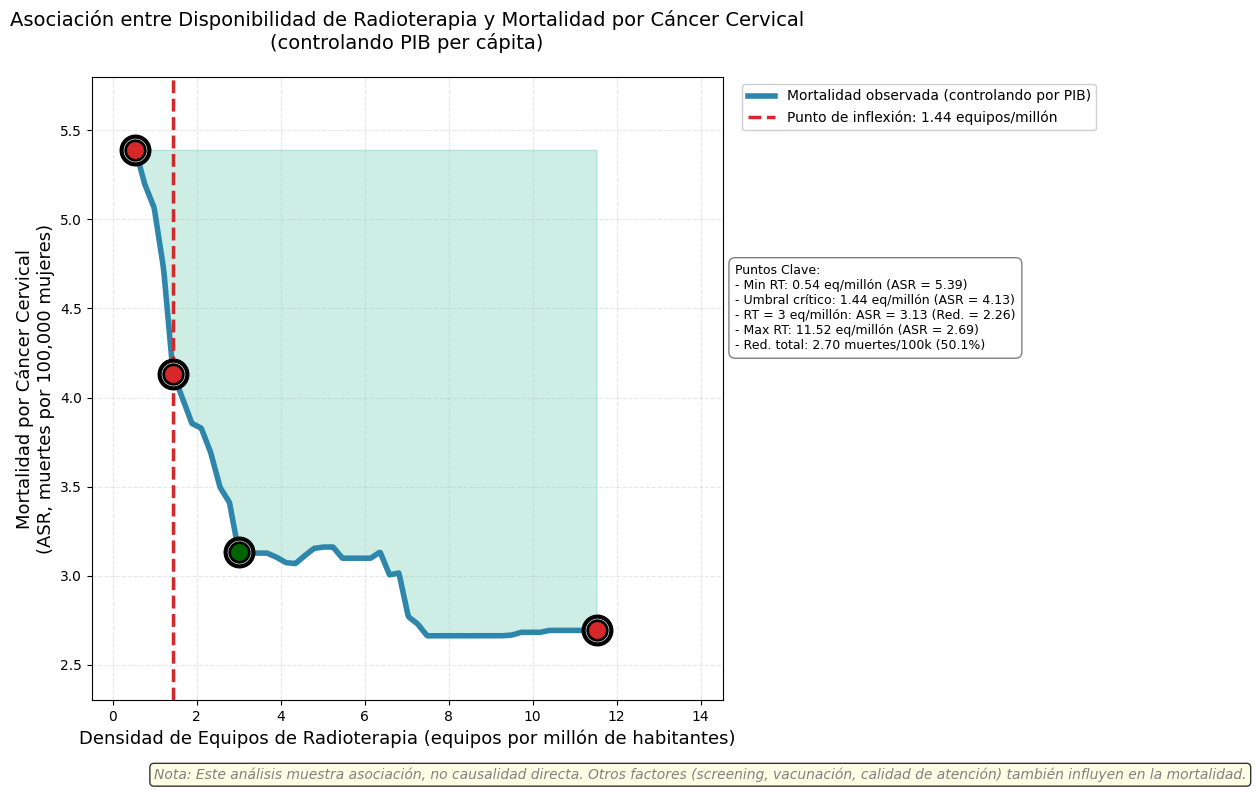

In [58]:
rf = rf_model # Assuming rf_model is the trained Random Forest model
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
rf.fit(X, y)

pdp_result = partial_dependence(rf, X, features=[1], grid_resolution=50)
rt_values = pdp_result['grid_values'][0]
asr_effect = pdp_result['average'][0]

# Calculate values for RT=3
rt_target = 3.0
asr_at_rt3 = np.interp(rt_target, rt_values, asr_effect)

asr_min_rt = asr_effect[0] # ASR with minimum RT
reduccion_rt3 = asr_min_rt - asr_at_rt3 # Reduction from min RT to RT=3
reduccion_total_actual = asr_effect[0] - asr_effect[-1]


fig, ax = plt.subplots(figsize=(14, 8))

# Curva del modelo
# Use interpolation to get a smoother curve over the actual rt_values for plotting
rt_plot_values = np.linspace(rt_values.min(), rt_values.max(), 500)
asr_plot_effect = np.interp(rt_plot_values, rt_values, asr_effect)

ax.plot(rt_plot_values, asr_plot_effect, linewidth=4, color='#2E86AB',
        label='Mortalidad observada (controlando por PIB)')

# Área de reducción
ax.fill_between(rt_plot_values, asr_plot_effect, asr_min_rt, alpha=0.2, color='#06A77D')

# Umbral (punto de inflexión) from previous calculation
umbral_rt = 1.44 # Based on previous analysis in cell dKZh3T1Fg9dz
ax.axvline(umbral_rt, color='#D62828', linestyle='--', linewidth=2.5,
           label=f'Punto de inflexión: {umbral_rt:.2f} equipos/millón', zorder=5)

# Key points markers (without text annotations here)
puntos_clave_data = [
    (rt_values[0], asr_effect[0]),
    (umbral_rt, np.interp(umbral_rt, rt_values, asr_effect)),
    (rt_values[-1], asr_effect[-1])
]

for x_point, y_point in puntos_clave_data:
    ax.scatter(x_point, y_point, s=400, color='white', edgecolors='black',
               linewidth=3, zorder=10)
    ax.scatter(x_point, y_point, s=200, color='#D62828', edgecolors='black',
               linewidth=2, zorder=11)

# Marker for RT=3
ax.scatter(rt_target, asr_at_rt3, s=400, color='white', edgecolors='black',
           linewidth=3, zorder=10)
ax.scatter(rt_target, asr_at_rt3, s=200, color='darkgreen', edgecolors='black',
           linewidth=2, zorder=11)

# Labels and format
ax.set_xlabel('Densidad de Equipos de Radioterapia (equipos por millón de habitantes)',
              fontsize=13)
ax.set_ylabel('Mortalidad por Cáncer Cervical\n(ASR, muertes por 100,000 mujeres)',
              fontsize=13)
ax.set_title('Asociación entre Disponibilidad de Radioterapia y Mortalidad por Cáncer Cervical\n(controlando PIB per cápita)',
             fontsize=14, pad=20)

# Main legend
ax.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1), framealpha=0.95)
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_xlim(-0.5, rt_values.max() + 3) # Adjust x-limit to accommodate new annotation
ax.set_ylim(2.3, 5.8)

# Create summary text for key points
key_points_summary = (
    f"Puntos Clave:\n"
    f"- Min RT: {rt_values[0]:.2f} eq/millón (ASR = {asr_effect[0]:.2f})\n"
    f"- Umbral crítico: {umbral_rt:.2f} eq/millón (ASR = {np.interp(umbral_rt, rt_values, asr_effect):.2f})\n"
    f"- RT = {rt_target:.0f} eq/millón: ASR = {asr_at_rt3:.2f} (Red. = {reduccion_rt3:.2f})\n"
    f"- Max RT: {rt_values[-1]:.2f} eq/millón (ASR = {asr_effect[-1]:.2f})\n"
    f"- Red. total: {reduccion_total_actual:.2f} muertes/100k ({(reduccion_total_actual/asr_effect[0])*100:.1f}%)"
)

# Place the summary text in the upper right, below the main legend
ax.text(1.02, 0.7, key_points_summary,
        transform=ax.transAxes, fontsize=9, ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', linewidth=1))

# Note al pie (IMPORTANT for honesty)
fig.text(0.5, 0.02,
         'Nota: Este análisis muestra asociación, no causalidad directa. ' +
         'Otros factores (screening, vacunación, calidad de atención) también influyen en la mortalidad.',
         ha='center', fontsize=10, style='italic', color='gray',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0.04, 0.8, 1]) # Adjusted rect to leave space for external annotations
plt.savefig('presentacion_RT_profesional_with_RT3.png', dpi=300, bbox_inches='tight')
plt.show()

ahroa lo graficamos

 UMBRALES DETECTADOS POR DECISION TREE:
   Umbral 1: RT = 1.34 equipos/millón
   Umbral 2: RT = 4.46 equipos/millón


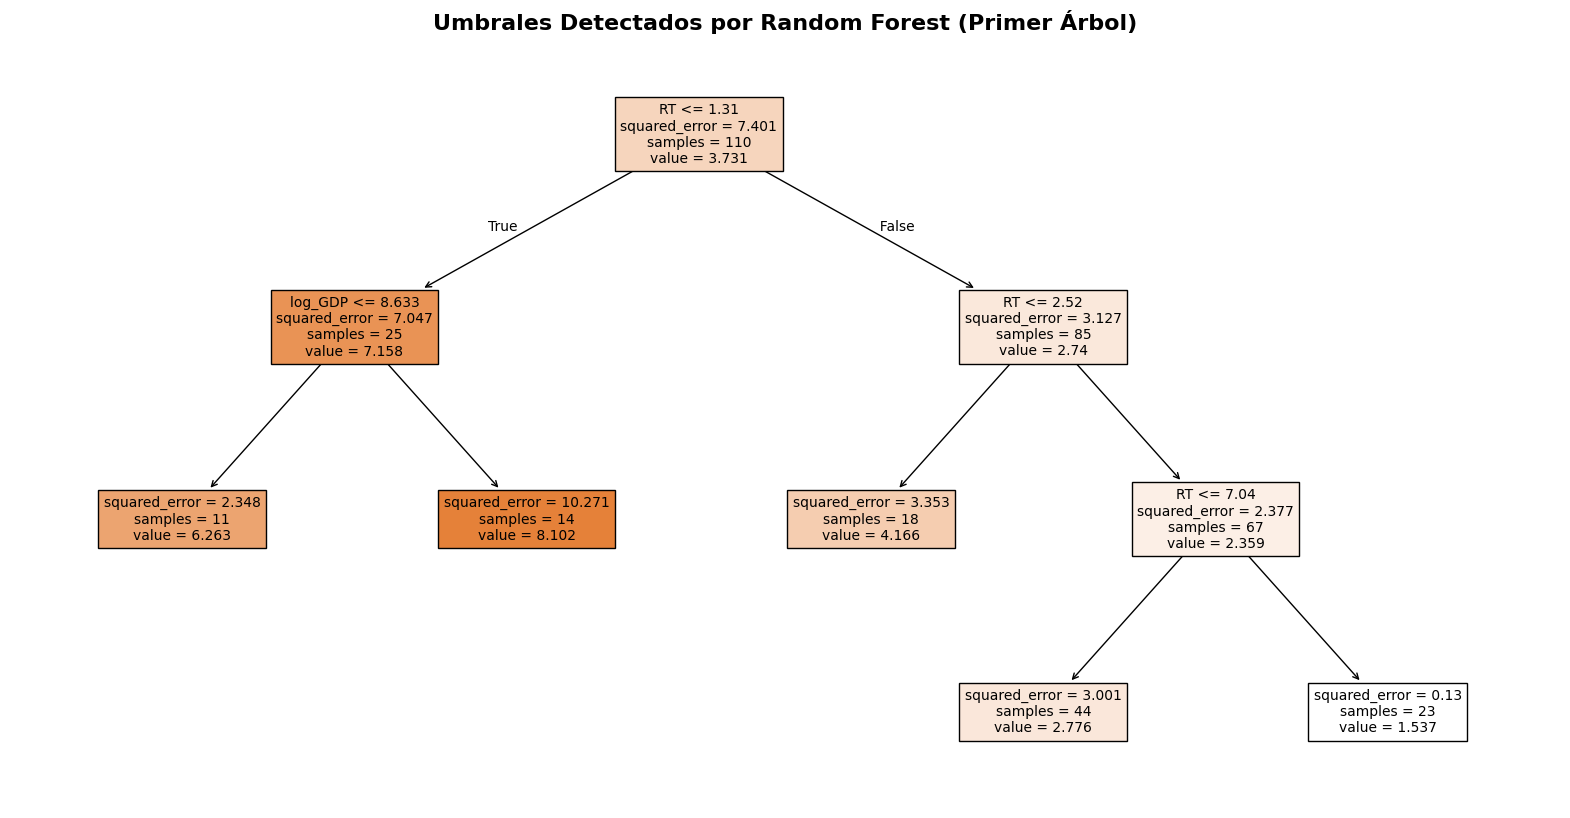


 UMBRALES DETECTADOS POR RANDOM FOREST:
   Umbral 1: RT = 1.61 (usado en 43 árboles)
   Umbral 2: RT = 6.94 (usado en 20 árboles)
   Umbral 3: RT = 4.43 (usado en 13 árboles)

 COMPARACIÓN DE MODELOS:
   Decision Tree R² (CV): 0.4591
   Random Forest R² (CV): 0.5615
   Diferencia: 0.1024


In [59]:
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# ============================================
# MÉTODO 1: ÁRBOL SIMPLE (INTERPRETABLE)
# ============================================
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree.fit(X, y)

# Extraer umbrales de RT automáticamente
umbrales_rt = []
for i, feature in enumerate(tree.tree_.feature):
    if feature == 1:  # RT es la columna 1
        umbral = tree.tree_.threshold[i]
        if umbral > 0:  # Válido
            umbrales_rt.append(umbral)

umbrales_rt = sorted(set(umbrales_rt))  # Únicos y ordenados

print("="*70)
print(" UMBRALES DETECTADOS POR DECISION TREE:")
for i, u in enumerate(umbrales_rt, 1):
    print(f"   Umbral {i}: RT = {u:.2f} equipos/millón")
print("="*70)

# Visualizar el primer árbol del Random Forest
# (o un árbol simple como antes, si se prefiere comparar)
plt.figure(figsize=(20, 10))
# plot_tree(tree, feature_names=['log_GDP', 'RT'], filled=True, fontsize=10)
plot_tree(rf_model.estimators_[0], feature_names=['log_GDP', 'RT'], filled=True, fontsize=10) # Plotting one tree from RF_model
plt.title("Umbrales Detectados por Random Forest (Primer Árbol)", fontsize=16, fontweight='bold')
plt.savefig('tree_umbrales_rf.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# MÉTODO 2: RANDOM FOREST
# ============================================
# Extraer umbrales de todos los árboles del RF
rf = rf_model
rf.fit(X, y)

umbrales_rf_todos = []
for tree_rf in rf.estimators_:
    for i, feature in enumerate(tree_rf.tree_.feature):
        if feature == 1:  # RT
            umbral = tree_rf.tree_.threshold[i]
            if 0.5 < umbral < 12:  # Rango válido
                umbrales_rf_todos.append(umbral)

# Encontrar umbrales más frecuentes (clustering)
umbrales_rf_todos = np.array(umbrales_rf_todos).reshape(-1, 1)
clusters = fclusterdata(umbrales_rf_todos, t=0.5, criterion='distance')

umbrales_rf = []
for cluster_id in np.unique(clusters):
    cluster_values = umbrales_rf_todos[clusters == cluster_id]
    umbral_medio = cluster_values.mean()
    frecuencia = len(cluster_values)
    if frecuencia > 10:  # Solo umbrales frecuentes
        umbrales_rf.append((umbral_medio, frecuencia))

umbrales_rf = sorted(umbrales_rf, key=lambda x: x[1], reverse=True)[:3]  # Top 3

print("\n UMBRALES DETECTADOS POR RANDOM FOREST:")
for i, (umbral, freq) in enumerate(umbrales_rf, 1):
    print(f"   Umbral {i}: RT = {umbral:.2f} (usado en {freq} árboles)")
print("="*70)

# ============================================
# COMPARACIÓN DE MÉTODOS
# ============================================
r2_tree = cross_val_score(tree, X, y, cv=5, scoring='r2').mean()
r2_rf = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()

print(f"\n COMPARACIÓN DE MODELOS:")
print(f"   Decision Tree R² (CV): {r2_tree:.4f}")
print(f"   Random Forest R² (CV): {r2_rf:.4f}")
print(f"   Diferencia: {r2_rf - r2_tree:.4f}")
print("="*70)

El árbol identifica RT ≤ 1.31 como el split más informativo (38% de reducción de MSE), separando países de alta mortalidad (ŷ=7.16) de baja (ŷ=2.74). En la rama de RT bajo, log_GDP subdivide en dos grupos (ŷ=6.26 vs. 8.10), donde el segundo presenta MSE=10.27 por outliers o confounders omitidos (screening, vacunas contra el VPH, etc). En RT alto, umbrales en 2.52 y 7.04 crean una progresión no lineal hasta la hoja óptima (RT > 7, MSE=0.13, ŷ=1.54). El árbol explica 52% de varianza localmente; RT muestra puntos de inflexión críticos en capacidad de tratamiento, mientras que log_GDP solo compensa cuando RT es insuficiente, sugiriendo una interacción clave. La alta dispersión en nodos pequeños sugiere la necesidad de incorporar variables adicionales (como la vacunación, IDH, etc) para capturar la heterogeneidad residual. No obstante, la obtención de datos adicionales ha representado un desafío significativo, atribuible principalmente a las limitaciones en la comunicación y al difícil acceso a la información en ciertos países, lo que ha conllevado una consecuente reducción del tamaño muestral disponible. Por ello, hemos optado por concluir este análisis utilizando las variables actuales, al tiempo que instamos a todos los países a compartir sus datos epidemiológicos. El propósito es avanzar hacia una comprensión más profunda del comportamiento de esta lamentable y extendida enfermedad. Esto, a su vez, establecería un ciclo virtuoso: una mayor disponibilidad de información conduciría a predicciones más robustas, y estas, a su vez, facilitarían estrategias de prevención más eficaces y tratamientos de radioterapia optimizados, basados en una evaluación precisa de las necesidades.

In [60]:
df_cervix.head()


,Year,Population,Population_female,ISO3,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET,log_GDP
4,2015,1292275.0,643934.0,MUS,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,0.000,9.172695
9,2018,1288833.0,642008.0,MUS,4.173902,Africa,2.41,11818.748062,6.43,2.41,4.82,0.000,9.377442
14,2022,1276130.0,637130.0,MUS,3.799936,Africa,3.14,10246.501746,NaN,NaN,NaN,NaN,9.234692
24,2015,56723537.0,29194266.0,ZAF,12.971971,Africa,0.60,6112.273825,1.02,0.56,0.24,0.060,8.718054
29,2018,58613001.0,30211846.0,ZAF,13.175513,Africa,0.57,6914.178032,0.97,0.53,0.23,0.057,8.841329


In [65]:
import plotly.express as px

fig = px.scatter(
    df_cervix,
    x="RT",
    y="ASR",
    hover_name="ISO3",
    hover_data={"GDP": True, "RT": True, "ISO3": True, "Year":True},
    title="Dispersión de ASR vs RT para Cáncer de Cérvix con datos de PIB y País en hover"
)

fig.update_layout(height=600, width=800)
fig.show()

In [80]:
import plotly.express as px

# Crear una copia del dataframe para evitar SettingWithCopyWarning
df_map = df_cervix.copy()

# Calcular la media de ASR para el df_cervix
mean_asr = df_cervix['ASR'].mean()

# Crear la columna de categoría basada en los umbrales de RT y el ASR medio
df_map['RT_Category'] = 'RT \u2265 3'

df_map.loc[(df_map['RT'] >= 1.44) & (df_map['RT'] < 3), 'RT_Category'] = '1.44 \u2264 RT < 3'

# Definir la nueva categoría para déficit de equipos Y ASR alta
df_map.loc[(df_map['RT'] < 1.44) & (df_map['ASR'] > mean_asr), 'RT_Category'] = 'RT < 1.44 y ASR > Media'

# Categoría para RT < 1.44 pero ASR <= Media
df_map.loc[(df_map['RT'] < 1.44) & (df_map['ASR'] <= mean_asr), 'RT_Category'] = 'RT < 1.44 y ASR \u2264 Media'


# Ordenar por año y quedarse con el último registro por país (para evitar duplicados si hay más de un año por país en el df_cervix filtrado)
df_map_latest_year = df_map.sort_values('Year').groupby('ISO3').last().reset_index()

# Crear el mapa coroplético
fig = px.choropleth(
    df_map_latest_year,
    locations='ISO3',
    color='RT_Category', # Colorear según la nueva categoría
    hover_name='ISO3',
    hover_data={'RT': ':.2f', 'log_GDP': ':.2f', 'ASR': ':.2f', 'Year': True},
    color_discrete_map={
        'RT < 1.44 y ASR > Media': 'darkred', # Nuevo color para el caso de interés
        'RT < 1.44 y ASR \u2264 Media': 'red', # Rojo normal para bajo RT pero ASR controlada
        '1.44 \u2264 RT < 3': 'orange',
        'RT \u2265 3': 'green'
    },
    title=f'Países según la Densidad de Equipos de Radioterapia (RT) y ASR (Media ASR = {mean_asr:.2f})',
    projection='natural earth'
)

fig.update_geos(showcountries=True, countrycolor="Black", showland=True, landcolor="lightgray")
fig.update_layout(height=600, width=1200)
fig.show()


In [81]:
# Guardar el mapa como imagen PNG
fig.write_image(f"{fig_dir}/mapa_RT_categorias.png", scale=2)

# Guardar el mapa como archivo HTML interactivo
fig.write_html("mapa_RT_categorias.html", auto_open=False)

print(f"Mapa guardado como '{fig_dir}/mapa_RT_categorias.png' y 'mapa_RT_categorias.html'.")

Mapa guardado como 'figuras/mapa_RT_categorias.png' y 'mapa_RT_categorias.html'.


### Países con RT < 1.44 equipos/millón de habitantes

In [82]:
df_rt_baja = df_map_latest_year[df_map_latest_year['RT_Category'] == 'RT < 1.44'].copy()
display(df_rt_baja[['ISO3', 'Year', 'ASR', 'RT', 'GDP', 'log_GDP']].sort_values('GDP'))

,ISO3,Year,ASR,RT,GDP,log_GDP


### Países con 1.44 ≤ RT < 3 equipos/millón de habitantes

In [83]:
df_rt_media = df_map_latest_year[df_map_latest_year['RT_Category'] == '1.44 \u2264 RT < 3'].copy()
display(df_rt_media[['ISO3', 'Year', 'ASR', 'RT', 'GDP', 'log_GDP']].sort_values('GDP'))

,ISO3,Year,ASR,RT,GDP,log_GDP
59,VEN,2015,9.740112,2.31,4103.138499,8.319507
17,ECU,2022,4.513753,1.59,6515.585284,8.781952
1,ARM,2022,3.074132,1.69,6571.974455,8.790570
10,COL,2018,5.631979,1.45,6816.968183,8.827170
6,BRA,2018,4.843195,1.74,9300.660729,9.137841
39,MEX,2022,5.359303,1.86,11405.794047,9.341877
45,PAN,2022,7.674046,2.32,17378.607002,9.762995


Este mapa te muestra los países coloreados según si su densidad de equipos de radioterapia (`RT`) está por debajo o por encima del umbral de 1.44. Los países en **rojo** tienen una densidad de RT **inferior a 1.44**, mientras que los países en **verde** tienen una densidad **igual o superior**. Al pasar el cursor sobre cada país, podrás ver su código ISO3, la densidad exacta de RT, el logaritmo del PIB per cápita y la ASR.